# 01 — Data preparation: ZIP-level master table

This notebook builds the **ZIP-code-level master table** for the Atlanta energy and urban-morphology
study. It starts from the ZIP (ZCTA) polygons that carry observed and modelled residential energy use,
then joins one data source per section:

- distance to the CBD
- MARTA rail access
- walkability
- Microsoft building footprints
- 2011 ACS/Census socioeconomic variables
- ARC LandPro 2012 land use
- EPA EQUATES CMAQ air quality (July 2010)

Every step, check and figure is in this notebook. Nothing runs in hidden scripts.

**Study unit.** 2010 Census ZIP Code Tabulation Areas (ZCTA5, TIGER/Line 2010). The **study ZIPs** are
the ZCTAs whose three energy predictions are all strictly positive: **190 ZIPs** (Section 3a). The
predictions come from the prior ZIP-level energy model (Random Forest and MATLAB regression): RF train,
RF cross-validated and MATLAB.

**Coordinate reference system.** All geometry work is done in **EPSG:2240**, NAD83 / Georgia West
(US survey feet). This is the projection used throughout the ArcGIS methodology.

**Units.**
- Areas are in **square feet** (`_sqft`), and ratios are per square foot.
- Distances are computed in feet and reported in **miles** (`_mi`, 1 mi = 5,280 ft).

**Pipeline.**
1. `data/raw`: inputs, never modified.
2. `data/interim`: CRS-standardised layers, the base and joined ZIP layers, and the socioeconomic
   codebook and tract table.
3. `data/processed`: the data dictionary.

### Data sources

| Dataset | Source | Vintage | Native CRS | Variables produced |
|---|---|---|---|---|
| ZIP energy clusters | TIGER/Line 2010 ZCTA polygons + the prior ZIP-level energy model and its HIGH/LOW clusters | ZCTA 2010; energy c. 2011 | EPSG:2240 | `energy_actual_kwh`, `pred_*_kwh`, `cluster`, `ZIP5`, `zip_area_sqft` |
| Model workbooks | The prior ZIP-level energy model | as above | tables | Checks of the prediction columns; predictor flags in the codebook |
| Atlanta CBD boundary | Provided with the study data | to be confirmed | EPSG:4269 | `Dist_CBD_mi` |
| MARTA rail stations | MARTA / Atlanta open data | 2025 | EPSG:3857 | `MARTA_stations_in_zip`, `has_MARTA_station`, `Dist_MARTA_Rail_mi`, `Nearest_MARTA_Station` |
| EPA National Walkability Index v3.0 | US EPA | v3.0 | EPSG:2240 | `NatWalkInd_zip`, `D3B_zip` |
| Microsoft US Building Footprints | Microsoft | imagery 2018–2020 | EPSG:4326 | `ms_*` |
| ZIP/tract socioeconomic file | Compilation of 2011 ACS/Census variables, provided with the study data | 2011 | tables | `se_v001` … `se_v356` |
| ARC LandPro 2012 | Atlanta Regional Commission (public open data) | 2012 | EPSG:2240 | `landpro_coverage_frac`, `lu_pct_*` |
| EPA EQUATES CMAQ v5.3.2, 12US1 grid | US EPA (public) | July 2010 (daily) | 12 km Lambert Conformal Conic grid (CSV) | `aq_*_jul2010` |

### Conventions
- **Join keys are text.** `ZIP5` is a zero-padded 5-character string and `TractGeoID` an 11-character
  string. Numeric keys lost leading zeros and broke joins in the ArcGIS workflow (methodology §9).
- **Distances are Euclidean**, measured from each ZIP's representative point. This is a deliberate
  choice (methodology §3), documented as a limitation.
- **MATLAB predictions are unreliable** (some are negative). The column is kept, but it should not be used
  for cross-scale comparisons without a caveat.
- **The HIGH/LOW cluster labels** are analyst judgment calls, not an established standard.

Background:
- [`docs/atlanta_methodology_arcgis.md`](../docs/atlanta_methodology_arcgis.md): the ArcGIS workflow
  this notebook reproduces.

## Reproducing this notebook

**Environment.** Python 3.13. From the repository root:

```bash
python -m venv .venv
.venv/Scripts/python -m pip install -r requirements.txt   # macOS/Linux: .venv/bin/python
.venv/Scripts/python -m ipykernel install --user --name atlanta-energy-morphology
```

`requirements.txt` pins the exact versions used for the committed run. Select the
`atlanta-energy-morphology` kernel.

**Raw inputs.** `data/` is gitignored, so place these files under `data/raw/` first. All paths in the
notebook are relative to `notebooks/`.

| Path under `data/raw/` | Content | Source |
|---|---|---|
| `vectors/tiger_energyclusters_2010_georgia_zipcode.gpkg` | Georgia 2010 ZCTA polygons joined to observed energy and model predictions | ZCTA geometry is public ([TIGER/Line 2010](https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html)). The energy attributes are provided with the study data, not redistributed. |
| `vectors/cbd_atlanta.gpkg` | Atlanta CBD boundary polygon | Provided with the study data, not redistributed |
| `vectors/MARTA_railstations_2025_georgia_zipcode.gpkg` (layer `marta_rail_stations`) | 38 MARTA rail stations | MARTA / Atlanta open data (public) |
| `vectors/EPA_walkabilityindex_2025_georgia_blockgroup.gpkg` | Georgia block groups with the National Walkability Index | [EPA National Walkability Index v3.0](https://www.epa.gov/smartgrowth/smart-location-mapping) (public) |
| `vectors/georgia_building_length_microsoft.gpkg` | Georgia building footprints, converted from GeoJSON with `ogr2ogr -f GPKG` | [Microsoft US Building Footprints](https://github.com/microsoft/USBuildingFootprints) (public) |
| `tables/May_Zip_Tract_regular_June_2.xlsx` | 2011 ACS/Census variables and residential energy for ZIPs and tracts, plus a codebook sheet | Provided with the study data, not redistributed |
| `tables/highEE_FullData.xlsx`, `tables/lowEE_FullData.xlsx` | The model workbooks for the HIGH and LOW clusters | Provided with the study data, not redistributed |
| `tables/zip_energy_socioeconomic_arcgis_ready.csv` | Superseded ArcGIS export, used only in the evidence table of Section 8 | Provided with the study data, not redistributed |
| `vectors/LandPro_2012.shp` (with `.shx`, `.dbf`, `.prj`, `.cpg`, `.shp.xml`) | ARC LandPro 2012 land-use polygons for the Atlanta Regional Commission region | Atlanta Regional Commission open data (public); committed to the repository |
| `tables/Daily_EQUATES_CMAQv532_cb6r3_ae7_aq_STAGE_12US1_201007.csv` | Daily CMAQ air-quality output for the continental US 12 km grid, July 2010 | [EPA EQUATES](https://www.epa.gov/cmaq/equates) (public). The file is large (816 MB) and is **not committed**; download it separately. |

**Run.** From `notebooks/`:

```bash
../.venv/Scripts/python -m jupyter nbconvert --to notebook --execute --inplace --ExecutePreprocessor.timeout=1800 01_data_preparation.ipynb
```

A full run takes a few minutes, mostly spent loading and reprojecting the ~4 million Microsoft
footprints, overlaying the LandPro polygons and scanning the air-quality CSV.

## 1. Setup

Imports, paths and the shared helpers:

- **`plot_choropleth` / `plot_choropleths`**: static geopandas/matplotlib maps, which render on GitHub
  and in PDF exports. ZIPs with no value are drawn in hatched grey.
- **`sanity_report`**: a summary table (n, nulls, quartiles, zeros, negatives) plus histograms.
- **`join_zip`**: a one-to-one left join on `ZIP5`. It prints how many ZIPs received each new column.

In [ ]:
import math
import re
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from IPython.display import display
from shapely.geometry import box

RAW_VECTORS = Path("../data/raw/vectors")
RAW_TABLES = Path("../data/raw/tables")
INTERIM = Path("../data/interim")
PROCESSED = Path("../data/processed")
INTERIM.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)

TARGET_CRS = "EPSG:2240"  # NAD83 / Georgia West (US survey feet), as in the ArcGIS methodology
FT_PER_MI = 5280

plt.rcParams.update({"figure.dpi": 80, "axes.titlesize": 10, "axes.labelsize": 9})
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)


def plot_choropleth(gdf, col, title, ax=None, cmap="viridis", overlay=None, legend_label=None):
    """Static choropleth of one column; missing values hatched grey; `overlay` drawn on top in red."""
    ax = ax or plt.subplots(figsize=(6, 5.5))[1]
    data = gdf[[col, "geometry"]].copy()
    kwargs = dict(column=col, ax=ax, cmap=cmap, legend=True, edgecolor="white", linewidth=0.2,
                  missing_kwds={"color": "lightgrey", "hatch": "///", "label": "No data"})
    if pd.api.types.is_bool_dtype(data[col]) or not pd.api.types.is_numeric_dtype(data[col]):
        data[col] = data[col].astype(str)
        kwargs.update(categorical=True, legend_kwds={"title": legend_label, "loc": "lower left", "fontsize": 8})
    else:
        kwargs["legend_kwds"] = {"label": legend_label or col, "shrink": 0.7}
    data.plot(**kwargs)
    if overlay is not None:
        overlay.plot(ax=ax, color="red", markersize=14, edgecolor="black", linewidth=0.4, zorder=3)
    ax.set_title(title)
    ax.set_axis_off()
    return ax


def plot_choropleths(gdf, cols, titles, ncols=2, legend_labels=None, **kwargs):
    """Grid of choropleths, one panel per column."""
    nrows = math.ceil(len(cols) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), squeeze=False)
    for ax, col, title, lab in zip(axes.flat, cols, titles, legend_labels or cols):
        plot_choropleth(gdf, col, title, ax=ax, legend_label=lab, **kwargs)
    fig.tight_layout()
    plt.show()


def sanity_report(df, cols, hist=True):
    """Summary table (n, nulls, quartiles, zeros, negatives) and histograms."""
    x = df[cols].astype("float64")
    report = pd.DataFrame({
        "n": x.count(), "n_null": x.isna().sum(), "pct_null": (x.isna().mean() * 100).round(1),
        "min": x.min(), "p25": x.quantile(0.25), "median": x.median(), "p75": x.quantile(0.75), "max": x.max(),
        "n_zero": (x == 0).sum(), "n_negative": (x < 0).sum(),
    })
    display(report)
    if hist:
        ncols = min(4, len(cols))
        axes = x.hist(bins=30, color="steelblue", grid=False, layout=(math.ceil(len(cols) / ncols), ncols),
                      figsize=(3.6 * ncols, 2.8 * math.ceil(len(cols) / ncols)))
        plt.tight_layout()
        plt.show()


def join_zip(gdf, new):
    """One-to-one left join of `new` (indexed by ZIP5) onto `gdf`; prints the match count per column."""
    out = gdf.join(new, on="ZIP5", validate="one_to_one")
    assert len(out) == len(gdf)
    print(out[new.columns].notna().sum().rename(f"ZIPs matched (of {len(out)})").to_string())
    return out

## 2. Vector inventory and CRS

**Data.** Every layer of every GeoPackage in `data/raw/vectors`.

**Method.** Only the CRS of each layer is read here. Layers not already in EPSG:2240 are reprojected on
load with `.to_crs(TARGET_CRS)`, which leaves layers already in EPSG:2240 unchanged.

**Why EPSG:2240.**
- It is the projection of the ArcGIS workflow being reproduced, so areas and distances are directly
  comparable with it.
- It is a conformal projection designed for this part of Georgia, so planar distances and areas are
  accurate to well under 0.1% across the study area.

**Caveats.**
- The MARTA GeoPackage has two layers, so the station layer is always loaded by name.
- "ft" means US survey feet. The 2 ppm difference from international feet is negligible.
- LandPro (Section 9) is a shapefile, not a GeoPackage, and is already in EPSG:2240.
- Rasters are not used yet (Section 13).

In [ ]:
pd.DataFrame(
    [{"file": f.name, "layer": layer, "crs": gpd.read_file(f, layer=layer, rows=1).crs.to_string()}
     for f in sorted(RAW_VECTORS.glob("*.gpkg")) for layer in gpd.list_layers(f)["name"]]
).assign(matches_target=lambda d: d["crs"] == TARGET_CRS)

,file,layer,crs,matches_target
0,cbd_atlanta.gpkg,atlanta_cbd,EPSG:4269,False
1,EPA_walkabilityindex_2025_georgia_blockgroup.gpkg,walkability_index,EPSG:2240,True
2,georgia_building_length_microsoft.gpkg,georgia_building_length_microsoft,EPSG:4326,False
3,MARTA_railstations_2025_georgia_zipcode.gpkg,marta_rail_stations,EPSG:3857,False
4,MARTA_railstations_2025_georgia_zipcode.gpkg,walkability_index,EPSG:2240,True
5,tiger_energyclusters_2010_georgia_zipcode.gpkg,tiger_energyclusters_2010_georgia_zipcode,EPSG:2240,True


## 3. Base layer: ZIP energy clusters

**Data.** `tiger_energyclusters_2010_georgia_zipcode.gpkg` holds the Georgia 2010 ZCTA polygons
(TIGER/Line 2010 attributes). They were joined in ArcGIS to the prior ZIP-level energy model's table,
which adds:
- the observed residential energy use;
- three model predictions;
- the HIGH/LOW cluster label.

The layer is already in EPSG:2240. The table below documents every column.

**Method.**
- **3a** filters the layer to the study ZIPs.
- **3b** verifies the prediction columns against the model workbooks and renames them.
- **3c** builds a text join key and the ZIP area.

The base layer is saved **before** any join.

**Caveats.**
- **Every ZCTA appears twice.** The layer is the union of a HIGH-cluster copy and a LOW-cluster copy of
  all 735 Georgia ZCTAs (1,470 rows), with identical geometry. A ZIP's energy values sit only in the
  copy of its own cluster. The other copy, and both copies of ZCTAs outside the energy study, hold
  zeros rather than nulls. The code below asserts this structure.
- `zipcode` is a float copy of the ZIP code. ArcGIS renamed `ZipCode` because GeoPackage column names
  are case-insensitive, and it would have clashed with `zipcode`. It is not used as a key.

In [ ]:
zipcode_gdf = gpd.read_file(RAW_VECTORS / "tiger_energyclusters_2010_georgia_zipcode.gpkg").to_crs(TARGET_CRS)

BASE_COLUMN_DOCS = pd.DataFrame(
    [
        ("STATEFP10", "State FIPS code (13 = Georgia)", "code", "TIGER/Line 2010 ZCTA"),
        ("ZCTA5CE10", "5-digit ZCTA code; source of the ZIP5 key", "code", "TIGER/Line 2010 ZCTA"),
        ("GEOID10", "State FIPS + ZCTA", "code", "TIGER/Line 2010 ZCTA"),
        ("CLASSFP10", "Census class code", "code", "TIGER/Line 2010 ZCTA"),
        ("MTFCC10", "MAF/TIGER feature class code", "code", "TIGER/Line 2010 ZCTA"),
        ("FUNCSTAT10", "Functional status", "code", "TIGER/Line 2010 ZCTA"),
        ("ALAND10", "Land area (not used; see zip_area_sqft)", "sq m", "TIGER/Line 2010 ZCTA"),
        ("AWATER10", "Water area", "sq m", "TIGER/Line 2010 ZCTA"),
        ("INTPTLAT10", "Latitude of the Census internal point", "degrees", "TIGER/Line 2010 ZCTA"),
        ("INTPTLON10", "Longitude of the Census internal point", "degrees", "TIGER/Line 2010 ZCTA"),
        ("PARTFLG10", "Partial-ZCTA flag", "flag", "TIGER/Line 2010 ZCTA"),
        ("energy_kwh", "Observed residential energy use (identical to energy_actual_kwh)", "kWh/yr", "Energy table (ArcGIS join)"),
        ("pop", "Total population", "persons", "Energy table (ArcGIS join)"),
        ("zipcode", "ZIP code as float (ArcGIS rename of ZipCode; not a key)", "code", "Energy table (ArcGIS join)"),
        ("OBJECTID_1", "ArcGIS object ID of the joined energy table", "id", "ArcGIS"),
        ("ZCTA", "ZCTA code as float, from the prediction table", "code", "Model predictions (ArcGIS join)"),
        ("lat", "Latitude used in the model workbooks", "degrees", "Model predictions (ArcGIS join)"),
        ("lon", "Longitude used in the model workbooks", "degrees", "Model predictions (ArcGIS join)"),
        ("predictedR", "Random-forest prediction, training fit (renamed pred_RF_train_kwh)", "kWh/yr", "Model predictions (ArcGIS join)"),
        ("predicte_1", "Random-forest prediction, cross-validated (renamed pred_RF_cv_kwh)", "kWh/yr", "Model predictions (ArcGIS join)"),
        ("predictedm", "MATLAB model prediction; unreliable (renamed pred_MATLAB_kwh)", "kWh/yr", "Model predictions (ArcGIS join)"),
        ("actual", "Observed residential energy use (renamed energy_actual_kwh)", "kWh/yr", "Model predictions (ArcGIS join)"),
        ("OBJECTID_2", "ArcGIS object ID of the joined prediction table", "id", "ArcGIS"),
        ("cluster", "HIGH / LOW energy cluster (analyst judgment call)", "category", "Model predictions (ArcGIS join)"),
        ("Shape_Leng", "Perimeter computed by ArcGIS", "ft", "ArcGIS"),
        ("Shape_Area", "Area computed by ArcGIS", "sq ft", "ArcGIS"),
    ],
    columns=["column", "description", "unit", "source"],
)
assert set(BASE_COLUMN_DOCS["column"]) == set(zipcode_gdf.columns.drop("geometry"))
display(BASE_COLUMN_DOCS.assign(dtype=BASE_COLUMN_DOCS["column"].map(zipcode_gdf.dtypes.astype(str)),
                                n_null=BASE_COLUMN_DOCS["column"].map(zipcode_gdf.isna().sum())))

# Structure: one HIGH and one LOW copy of each ZCTA, same geometry, energy values in at most one copy.
copies = zipcode_gdf.groupby("ZCTA5CE10")
print(f"rows: {len(zipcode_gdf)}, unique ZCTAs: {zipcode_gdf['ZCTA5CE10'].nunique()}")
assert (copies.size() == 2).all() and copies["cluster"].agg(lambda s: sorted(s) == ["HIGH", "LOW"]).all()
assert copies["geometry"].agg(lambda g: g.iloc[0].equals(g.iloc[1])).all()
assert (copies["actual"].agg(lambda s: (s != 0).sum()) <= 1).all()

PRED_COLS = ["predictedR", "predicte_1", "predictedm"]
x = zipcode_gdf[PRED_COLS + ["actual"]]
pd.DataFrame({"n_negative": (x < 0).sum(), "n_zero": (x == 0).sum(), "n_positive": (x > 0).sum(), "min": x.min(), "max": x.max()})

,column,description,unit,source,dtype,n_null
0,STATEFP10,State FIPS code (13 = Georgia),code,TIGER/Line 2010 ZCTA,str,0
1,ZCTA5CE10,5-digit ZCTA code; source of the ZIP5 key,code,TIGER/Line 2010 ZCTA,str,0
2,GEOID10,State FIPS + ZCTA,code,TIGER/Line 2010 ZCTA,str,0
3,CLASSFP10,Census class code,code,TIGER/Line 2010 ZCTA,str,0
4,MTFCC10,MAF/TIGER feature class code,code,TIGER/Line 2010 ZCTA,str,0
5,FUNCSTAT10,Functional status,code,TIGER/Line 2010 ZCTA,str,0
6,ALAND10,Land area (not used; see zip_area_sqft),sq m,TIGER/Line 2010 ZCTA,float64,0
7,AWATER10,Water area,sq m,TIGER/Line 2010 ZCTA,float64,0
8,INTPTLAT10,Latitude of the Census internal point,degrees,TIGER/Line 2010 ZCTA,str,0
9,INTPTLON10,Longitude of the Census internal point,degrees,TIGER/Line 2010 ZCTA,str,0


rows: 1470, unique ZCTAs: 735


,n_negative,n_zero,n_positive,min,max
predictedR,0,1274,196,0.000000e+00,2.385561e+08
predicte_1,0,1274,196,0.000000e+00,2.372912e+08
predictedm,6,1274,190,-1.651786e+06,2.615447e+08
actual,0,1274,196,0.000000e+00,2.769300e+08


### 3a. Study-area filter

A row is kept only if **all three** predictions (`predictedR`, `predicte_1`, `predictedm`) are strictly
positive.

- **All-zero rows are dropped.** They are either the other-cluster copy of a study ZIP or a ZCTA
  outside the energy study.
- **Negative MATLAB rows are dropped.** A negative energy prediction is physically meaningless and
  would break any ratio or log comparison between models.

This gives every retained ZIP a complete, comparable set of predictions.

For the map, each ZCTA gets one status: **kept** if either copy is kept, **dropped** if a copy has
energy values but fails the filter, and **outside energy study** otherwise.

,ZCTA5CE10,cluster,predictedR,predicte_1,predictedm,actual
914,30536,LOW,5.524790e+06,6.183289e+06,-4.085366e+05,86727.0
1046,30286,LOW,5.365566e+06,5.583124e+06,-1.651786e+06,13848.0
1047,30622,LOW,3.518896e+06,3.282255e+06,-1.584955e+06,290954.0
1056,30268,LOW,6.717602e+06,7.293027e+06,-2.732736e+05,221179.0
1061,31085,LOW,6.610496e+06,6.236599e+06,-6.243865e+04,4499010.0
1086,30161,LOW,7.796291e+06,5.868694e+06,-1.203719e+06,1228183.0


,ZCTAs
study_status,
outside energy study,539
kept,190
dropped: non-positive prediction,6


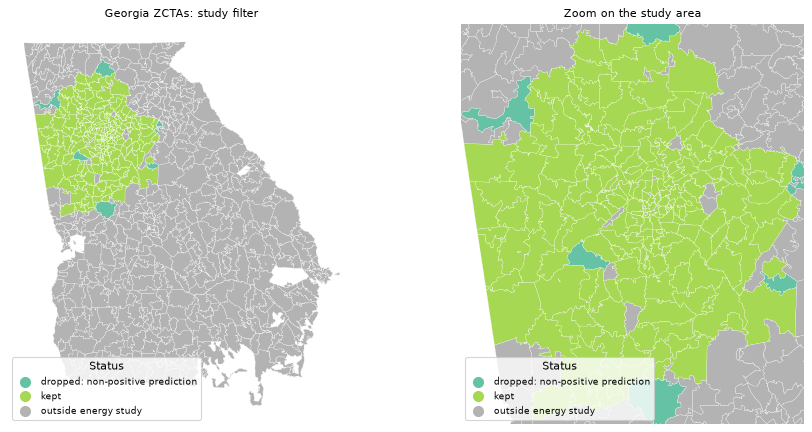

In [ ]:
keep = (zipcode_gdf[PRED_COLS] > 0).all(axis=1)
all_zero = (zipcode_gdf[PRED_COLS] == 0).all(axis=1)
display(zipcode_gdf.loc[~keep & ~all_zero, ["ZCTA5CE10", "cluster", *PRED_COLS, "actual"]])

status = pd.Categorical(
    np.select([keep, all_zero], ["kept", "outside energy study"], "dropped: non-positive prediction"),
    categories=["kept", "dropped: non-positive prediction", "outside energy study"], ordered=True,
)
zcta_status = zipcode_gdf.assign(study_status=status).sort_values("study_status").drop_duplicates("ZCTA5CE10")
display(zcta_status["study_status"].value_counts().rename("ZCTAs").to_frame())

zipcode_gdf = zipcode_gdf[keep].reset_index(drop=True)
assert len(zipcode_gdf) == 190 and zipcode_gdf["ZCTA5CE10"].is_unique

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, title in zip(axes, ["Georgia ZCTAs: study filter", "Zoom on the study area"]):
    plot_choropleth(zcta_status, "study_status", title, ax=ax, cmap="Set2", legend_label="Status")
minx, miny, maxx, maxy = zipcode_gdf.total_bounds
axes[1].set(xlim=(minx - 5000, maxx + 5000), ylim=(miny - 5000, maxy + 5000))
fig.tight_layout()
plt.show()

### 3b. Prediction column identities and renames

ArcGIS truncated the prediction field names. To confirm which model each column holds, they are
compared with the `RF_ZCTA_Estimates` sheet of each model workbook.

That sheet has no ZIP column. It is row-aligned with the workbook's coordinates sheet, which supplies
the ZCTA:
- `ZipCode Coordinates` in the HIGH workbook;
- `Coordinates` in the LOW workbook.

The mapping is accepted only if **every** study ZIP matches (`np.isclose`).

| Original | New | Meaning |
|---|---|---|
| `predictedR` | `pred_RF_train_kwh` | Random forest, training-set fit |
| `predicte_1` | `pred_RF_cv_kwh` | Random forest, cross-validated |
| `predictedm` | `pred_MATLAB_kwh` | MATLAB regression (unreliable) |
| `actual` | `energy_actual_kwh` | Observed residential energy use, kWh/yr |

In [ ]:
MODEL_WORKBOOKS = {"HIGH": ("highEE_FullData.xlsx", "ZipCode Coordinates"), "LOW": ("lowEE_FullData.xlsx", "Coordinates")}
PRED_SOURCE_MAP = {"predictedR": "predictedRF_train", "predicte_1": "predictedRF_cv_train",
                   "predictedm": "predictedmatlab_train", "actual": "actual"}
zipcode_gdf["ZIP5"] = zipcode_gdf["ZCTA5CE10"].str.zfill(5)

identity, workbook_zips = {}, {}
for label, (fname, coord_sheet) in MODEL_WORKBOOKS.items():
    est = pd.read_excel(RAW_TABLES / fname, sheet_name="RF_ZCTA_Estimates").add_prefix("wb_")
    est["ZIP5"] = pd.read_excel(RAW_TABLES / fname, sheet_name=coord_sheet)["ZCTA"].astype("int64").astype(str).str.zfill(5)
    workbook_zips[label] = set(est["ZIP5"])
    m = est.merge(zipcode_gdf[["ZIP5", "cluster", *PRED_SOURCE_MAP]], on="ZIP5")
    identity[fname] = {"n_rows": len(est), "n_in_study": len(m), "cluster label agrees (%)": (m["cluster"] == label).mean() * 100,
                       **{f"{b} == {w} (%)": np.isclose(m[b], m[f"wb_{w}"]).mean() * 100 for b, w in PRED_SOURCE_MAP.items()}}
    print(f"{fname}: workbook ZIPs not in the study set: {sorted(workbook_zips[label] - set(zipcode_gdf['ZIP5']))}")
identity = pd.DataFrame(identity)
display(identity)
assert (identity.iloc[2:] == 100).all().all(), "prediction identities do not all match"

in_high, in_low = zipcode_gdf["ZIP5"].isin(workbook_zips["HIGH"]), zipcode_gdf["ZIP5"].isin(workbook_zips["LOW"])
assert (in_high ^ in_low).all(), "every study ZIP must be in exactly one workbook"
assert np.allclose(zipcode_gdf["energy_kwh"], zipcode_gdf["actual"])

PRED_RENAME = {"predictedR": "pred_RF_train_kwh", "predicte_1": "pred_RF_cv_kwh",
               "predictedm": "pred_MATLAB_kwh", "actual": "energy_actual_kwh"}
zipcode_gdf = zipcode_gdf.rename(columns=PRED_RENAME)
ENERGY_COLS = list(PRED_RENAME.values())

highEE_FullData.xlsx: workbook ZIPs not in the study set: []
lowEE_FullData.xlsx: workbook ZIPs not in the study set: ['30161', '30268', '30286', '30536', '30622', '31085']


,highEE_FullData.xlsx,lowEE_FullData.xlsx
n_rows,63.0,133.0
n_in_study,63.0,127.0
cluster label agrees (%),100.0,100.0
predictedR == predictedRF_train (%),100.0,100.0
predicte_1 == predictedRF_cv_train (%),100.0,100.0
predictedm == predictedmatlab_train (%),100.0,100.0
actual == actual (%),100.0,100.0


### 3c. Join key `ZIP5` and ZIP area `zip_area_sqft`

**`ZIP5`** (built above) is `ZCTA5CE10` as a zero-padded **5-character string**. Text keys avoid the
numeric-key join failures of the ArcGIS workflow (methodology §9).

**`zip_area_sqft`** is the planar polygon area in EPSG:2240. It is the **denominator of every area
metric**, so numerator and denominator always come from the same CRS.
- `ALAND10` is not used: it is in square metres and covers land only.
- `Shape_Area` is not used: ArcGIS computed it, and it would go stale if the geometry were edited.

The table below shows that the three areas agree.

In [ ]:
zipcode_gdf["zip_area_sqft"] = zipcode_gdf.area
assert zipcode_gdf["ZIP5"].is_unique and (zipcode_gdf["ZIP5"].str.len() == 5).all()
SQFT_PER_SQM = 10.763910417
pd.DataFrame({
    "zip_area_sqft / Shape_Area": zipcode_gdf["zip_area_sqft"] / zipcode_gdf["Shape_Area"],
    "zip_area_sqft / (ALAND10+AWATER10 in sq ft)": zipcode_gdf["zip_area_sqft"] / ((zipcode_gdf["ALAND10"] + zipcode_gdf["AWATER10"]) * SQFT_PER_SQM),
}).describe().T

,count,mean,std,min,25%,50%,75%,max
zip_area_sqft / Shape_Area,190.0,1.000000,1.282204e-12,1.000000,1.000000,1.000000,1.000000,1.000000
zip_area_sqft / (ALAND10+AWATER10 in sq ft),190.0,0.999836,5.667579e-05,0.999796,0.999801,0.999813,0.999845,1.000069


### 3d. EDA and sanity check

The base layer must have 190 unique ZIPs, positive energy values and positive areas. It is saved as
`data/interim/zipcode_base.gpkg` before any join.

,n,n_null,pct_null,min,p25,median,p75,max,n_zero,n_negative
pred_RF_train_kwh,190,0,0.0,3.353218e+06,1.489640e+07,4.638131e+07,1.358345e+08,2.385561e+08,0,0
pred_RF_cv_kwh,190,0,0.0,3.581076e+06,1.340409e+07,4.612875e+07,1.368118e+08,2.372912e+08,0,0
pred_MATLAB_kwh,190,0,0.0,1.516537e+05,1.284556e+07,4.475886e+07,1.358905e+08,2.615447e+08,0,0
energy_actual_kwh,190,0,0.0,3.027000e+04,1.160786e+07,4.538675e+07,1.204905e+08,2.769300e+08,0,0
pop,190,0,0.0,7.300000e+02,1.197375e+04,2.522700e+04,3.802300e+04,8.024100e+04,0,0
zip_area_sqft,190,0,0.0,6.165076e+06,3.444678e+08,9.505842e+08,1.901016e+09,7.392685e+09,0,0


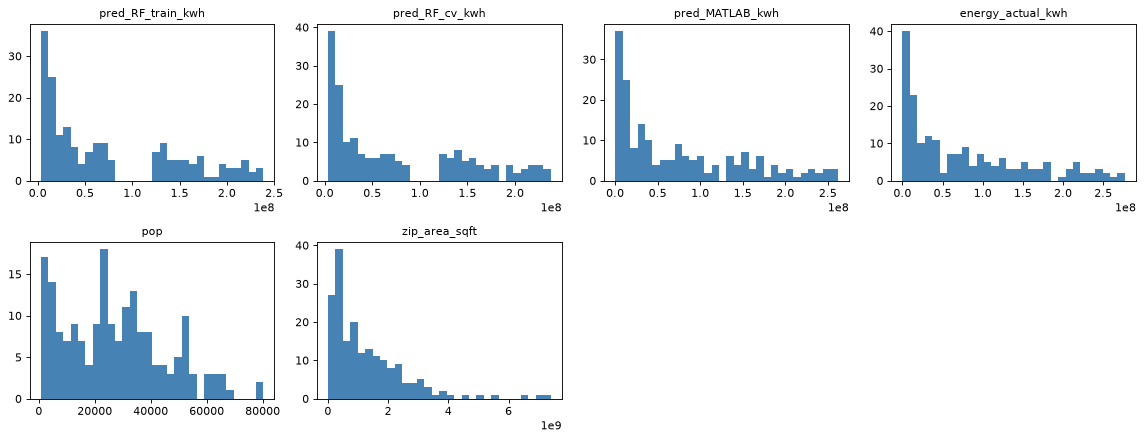

{'LOW': 127, 'HIGH': 63}


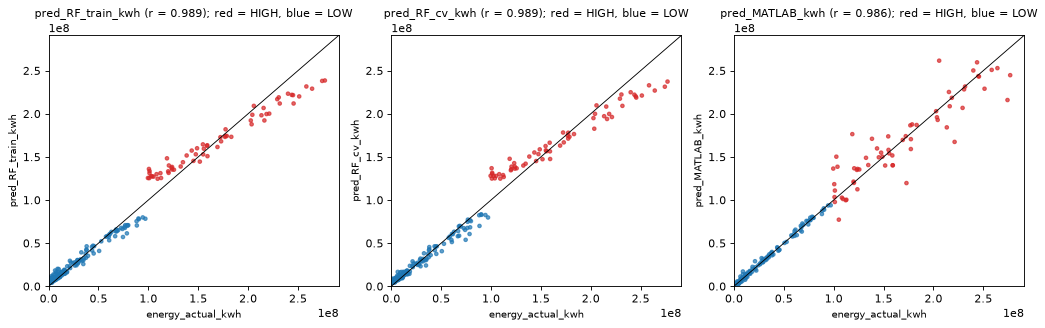

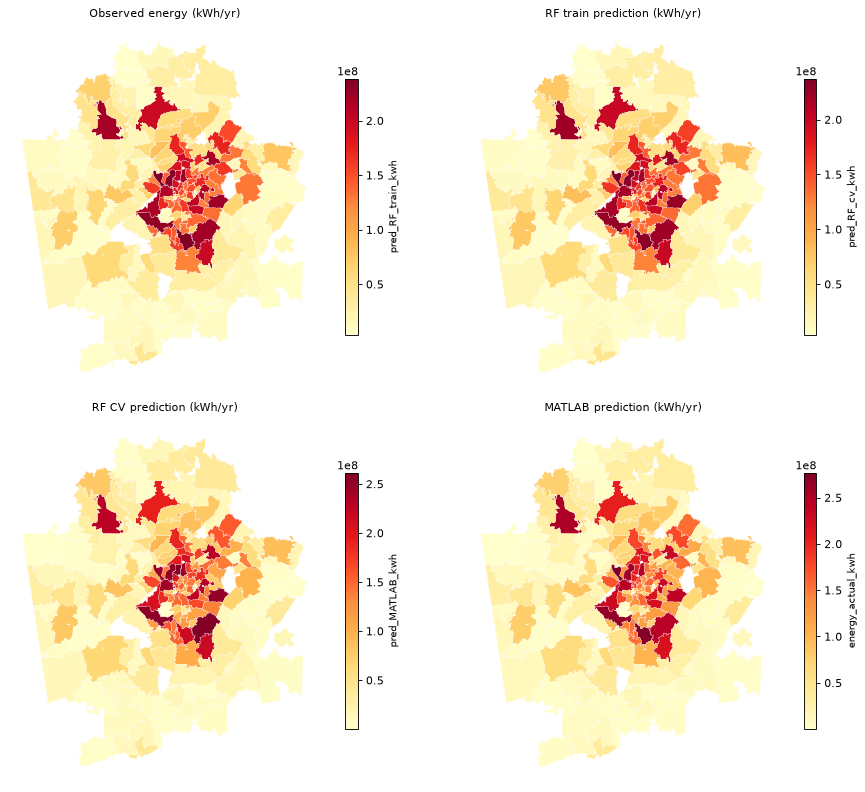

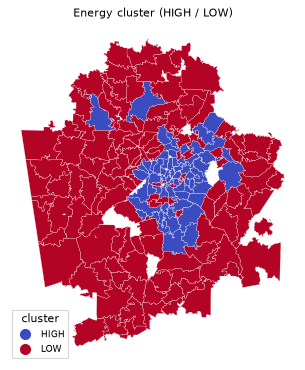

In [ ]:
sanity_report(zipcode_gdf, ENERGY_COLS + ["pop", "zip_area_sqft"])
assert (zipcode_gdf[ENERGY_COLS] > 0).all().all() and (zipcode_gdf["zip_area_sqft"] > 0).all()
print(zipcode_gdf["cluster"].value_counts().to_dict())

# Predicted vs. observed energy, one panel per model, with the 1:1 line.
colors = zipcode_gdf["cluster"].map({"HIGH": "tab:red", "LOW": "tab:blue"})
lim = [0, zipcode_gdf[ENERGY_COLS].max().max() * 1.05]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, col in zip(axes, ENERGY_COLS[:3]):
    ax.scatter(zipcode_gdf["energy_actual_kwh"], zipcode_gdf[col], s=10, c=colors, alpha=0.7)
    ax.plot(lim, lim, color="black", linewidth=0.8)
    r = np.corrcoef(zipcode_gdf["energy_actual_kwh"], zipcode_gdf[col])[0, 1]
    ax.set(xlim=lim, ylim=lim, xlabel="energy_actual_kwh", ylabel=col, title=f"{col} (r = {r:.3f}); red = HIGH, blue = LOW")
fig.tight_layout()
plt.show()

plot_choropleths(zipcode_gdf, ENERGY_COLS, ["Observed energy (kWh/yr)", "RF train prediction (kWh/yr)",
                                            "RF CV prediction (kWh/yr)", "MATLAB prediction (kWh/yr)"], cmap="YlOrRd")
plot_choropleth(zipcode_gdf, "cluster", "Energy cluster (HIGH / LOW)", cmap="coolwarm", legend_label="cluster")
plt.show()

zipcode_gdf.to_file(INTERIM / "zipcode_base.gpkg", driver="GPKG")

## 4. Distance to the CBD

**Data.** `cbd_atlanta.gpkg`: one polygon of the Atlanta central business district, provided with the
study data (EPSG:4269).

**Method.** `Dist_CBD_mi` is the Euclidean distance from each ZIP's **representative point** to the
CBD's representative point, computed in feet and divided by 5,280.

- **Why a representative point.** It is guaranteed to lie inside its polygon, the same as ArcGIS
  *Feature To Point* with "Inside" (methodology §3). A true centroid can fall outside a concave or
  multi-part polygon, such as an irregular ZIP or the CBD itself.
- **Why Euclidean.** It follows monocentric-city conventions and is the project's documented choice
  (methodology §3).

**Caveats.**
- Straight-line distance ignores the road network.
- For a large ZIP, one point summarises a wide range of distances.
- The vintage of the CBD boundary is to be confirmed.

**Sanity check.** Every distance must be positive. The map should show a smooth gradient centred on
downtown Atlanta.

Dist_CBD_mi    190


,n,n_null,pct_null,min,p25,median,p75,max,n_zero,n_negative
Dist_CBD_mi,190,0,0.0,0.812949,11.932972,25.341851,39.597787,70.300443,0,0


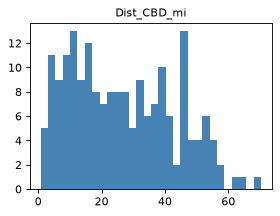

{'HIGH': 11.6, 'LOW': 34.1} (median mi by cluster)


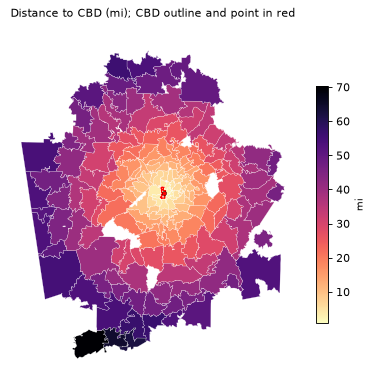

In [ ]:
cbd_gdf = gpd.read_file(RAW_VECTORS / "cbd_atlanta.gpkg").to_crs(TARGET_CRS)
assert len(cbd_gdf) == 1
cbd_point = gpd.GeoDataFrame(geometry=cbd_gdf.representative_point(), crs=TARGET_CRS)

zip_points = zipcode_gdf[["ZIP5", "geometry"]].assign(geometry=zipcode_gdf.representative_point())
zipcode_gdf = join_zip(zipcode_gdf, (zip_points.set_index("ZIP5").distance(cbd_point.geometry.iloc[0]) / FT_PER_MI).rename("Dist_CBD_mi").to_frame())

sanity_report(zipcode_gdf, ["Dist_CBD_mi"])
assert (zipcode_gdf["Dist_CBD_mi"] > 0).all()
print(zipcode_gdf.groupby("cluster")["Dist_CBD_mi"].median().round(1).to_dict(), "(median mi by cluster)")

ax = plot_choropleth(zipcode_gdf, "Dist_CBD_mi", "Distance to CBD (mi); CBD outline and point in red",
                     cmap="magma_r", overlay=cbd_point, legend_label="mi")
cbd_gdf.boundary.plot(ax=ax, color="red", linewidth=1)
plt.show()

## 5. MARTA rail stations

**Data.** Layer `marta_rail_stations` of `MARTA_railstations_2025_georgia_zipcode.gpkg`: 38 MARTA
heavy-rail stations (field `STATION`), 2025, EPSG:3857.

**Method.** Two complementary measures of rail access:
- **Stations within each ZIP.** A point-in-polygon join (`predicate="within"`) gives
  `MARTA_stations_in_zip` and the flag `has_MARTA_station`. ZIPs without a station get **0**, not NaN,
  because a missing station is a real zero.
- **Nearest-station distance.** `sjoin_nearest` from each ZIP's representative point gives
  `Dist_MARTA_Rail_mi` and `Nearest_MARTA_Station`. It is measured from the point, not the polygon:
  a distance to a polygon is 0 whenever a station lies inside it, which is how the first ArcGIS attempt
  failed (methodology §4).

**Caveats.**
- The station locations are from 2025, while the energy data is c. 2011. The heavy-rail network has
  not changed since the North Springs extension opened in 2000, so this does not matter for rail.
- Bus service is not included (Section 13).
- The count depends on ZIP size, so the flag and the distance are the more comparable measures.

**Sanity check.**
- The counts must sum to at most 38.
- Every distance must be positive.
- Stations outside every study ZIP must lie in ZCTAs excluded by the study filter, not in gaps between
  polygons.

In [ ]:
marta_gdf = gpd.read_file(RAW_VECTORS / "MARTA_railstations_2025_georgia_zipcode.gpkg", layer="marta_rail_stations").to_crs(TARGET_CRS)
assert len(marta_gdf) == 38

stations_in = gpd.sjoin(marta_gdf[["STATION", "geometry"]], zipcode_gdf[["ZIP5", "geometry"]], predicate="within")
zipcode_gdf["MARTA_stations_in_zip"] = zipcode_gdf["ZIP5"].map(stations_in["ZIP5"].value_counts()).fillna(0).astype(int)
zipcode_gdf["has_MARTA_station"] = zipcode_gdf["MARTA_stations_in_zip"] > 0
print(f"stations in study ZIPs: {zipcode_gdf['MARTA_stations_in_zip'].sum()} of 38; "
      f"ZIPs with at least one: {zipcode_gdf['has_MARTA_station'].sum()} of {len(zipcode_gdf)}")

outside = gpd.sjoin(marta_gdf.drop(stations_in.index)[["STATION", "geometry"]],
                    zcta_status[["ZCTA5CE10", "study_status", "geometry"]], how="left", predicate="within")
display(outside[["STATION", "ZCTA5CE10", "study_status"]])
assert outside["ZCTA5CE10"].notna().all(), "a station falls in no ZCTA at all"

nearest = gpd.sjoin_nearest(zip_points, marta_gdf[["STATION", "geometry"]], distance_col="dist_ft").drop_duplicates("ZIP5").set_index("ZIP5")
zipcode_gdf = join_zip(zipcode_gdf, pd.DataFrame({"Dist_MARTA_Rail_mi": nearest["dist_ft"] / FT_PER_MI,
                                                  "Nearest_MARTA_Station": nearest["STATION"]}))

stations in study ZIPs: 32 of 38; ZIPs with at least one: 20 of 190


,STATION,ZCTA5CE10,study_status
9,Georgia State,30334,outside energy study
21,Dunwoody,30346,outside energy study
25,Buckhead,30326,outside energy study
31,Peachtree Center,30303,outside energy study
32,Five Points,30303,outside energy study
34,Garnett,30303,outside energy study


Dist_MARTA_Rail_mi       190
Nearest_MARTA_Station    190


,n,n_null,pct_null,min,p25,median,p75,max,n_zero,n_negative
MARTA_stations_in_zip,190,0,0.0,0.000000,0.000000,0.000000,0.000000,3.000000,170,0
Dist_MARTA_Rail_mi,190,0,0.0,0.221225,5.771976,17.165982,31.487446,60.095507,0,0


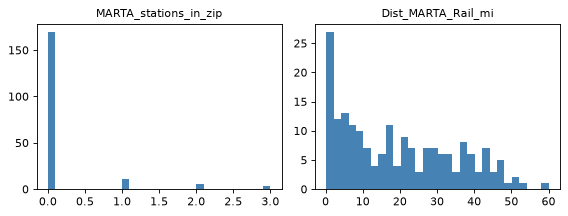

,count,mean,std,min,25%,50%,75%,max
has_MARTA_station,,,,,,,,
False,170.0,21.632922,14.706655,0.697813,8.152227,19.503231,33.542006,60.095507
True,20.0,1.045380,0.625865,0.221225,0.525712,0.941971,1.570691,2.309044


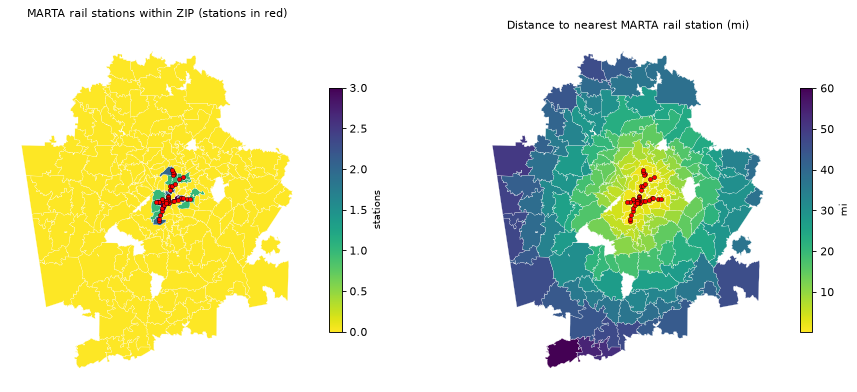

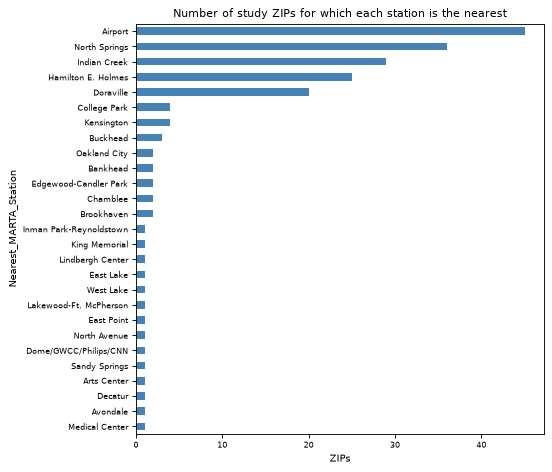

In [ ]:
sanity_report(zipcode_gdf, ["MARTA_stations_in_zip", "Dist_MARTA_Rail_mi"])
assert zipcode_gdf["MARTA_stations_in_zip"].sum() <= 38 and (zipcode_gdf["Dist_MARTA_Rail_mi"] > 0).all()
display(zipcode_gdf.groupby("has_MARTA_station")["Dist_MARTA_Rail_mi"].describe())

plot_choropleths(zipcode_gdf, ["MARTA_stations_in_zip", "Dist_MARTA_Rail_mi"],
                 ["MARTA rail stations within ZIP (stations in red)", "Distance to nearest MARTA rail station (mi)"],
                 legend_labels=["stations", "mi"], overlay=marta_gdf, cmap="viridis_r")

ax = zipcode_gdf["Nearest_MARTA_Station"].value_counts().sort_values().plot.barh(figsize=(7, 6), color="steelblue", fontsize=7)
ax.set(title="Number of study ZIPs for which each station is the nearest", xlabel="ZIPs")
plt.tight_layout()
plt.show()

## 6. Walkability (EPA National Walkability Index v3.0)

**Data.** `EPA_walkabilityindex_2025_georgia_blockgroup.gpkg`: the EPA National Walkability Index v3.0
for every Georgia block group (EPSG:2240). Two variables are used:
- `NatWalkInd`: the walkability index, from 1 (least walkable) to 20.
- `D3B`: pedestrian-oriented street intersections per square mile (methodology §5).

**Method.** Block groups do not nest inside ZCTAs, so the tract shortcut (`GEOID[:11]`) does not work
here. Instead, ZIPs and block groups are intersected (`gpd.overlay`), and each ZIP gets the
**area-weighted mean** of its pieces:

$$\bar{x}_z = \frac{\sum_{b} x_b \, A_{z \cap b}}{\sum_{b} A_{z \cap b}}$$

$A_{z \cap b}$ is the area (sq ft) of the part of block group $b$ that lies inside ZIP $z$. Area
weighting suits both variables: `D3B` is a density, and `NatWalkInd` is a spatial index, not a
per-person quantity.

**Caveats.**
- **`D4A` is excluded.** Its name collides with the full SLD's transit-distance field, and it carries a
  −99999 sentinel (methodology §5). Rail access is measured directly in Section 5.
- Area weighting assumes a value is uniform within its block group.
- NWI v3.0 is later than the c. 2011 energy data.

**Sanity check.**
- Block-group coverage of each ZIP should be ≈ 1. Any ZIP below 0.95 is flagged.
- Each ZIP mean must lie within the range of the block-group values.

block groups in Georgia: 5711, intersecting the study ZIPs: 2705
D4A == -99999 (sentinel) in these block groups: 1733


,n,n_null,pct_null,min,p25,median,p75,max,n_zero,n_negative
NatWalkInd,2705,0,0.0,1.0,5.666667,8.166667,11.500000,19.333333,0,0
D3B,2705,0,0.0,0.0,17.706344,39.451123,63.166761,954.493429,1,0
TotPop,2705,0,0.0,0.0,1311.000000,1927.000000,2764.000000,12037.000000,4,0
CountHU,2705,0,0.0,0.0,538.000000,776.000000,1077.000000,4073.000000,8,0


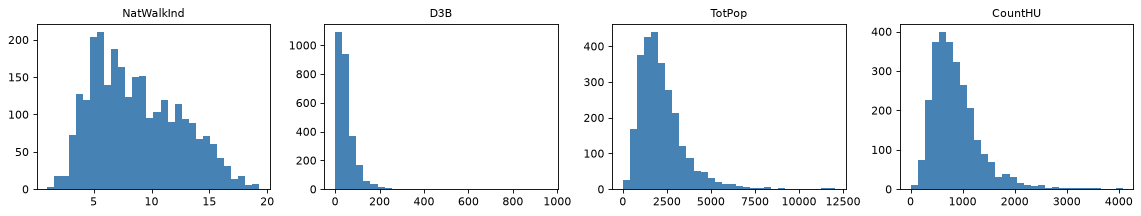

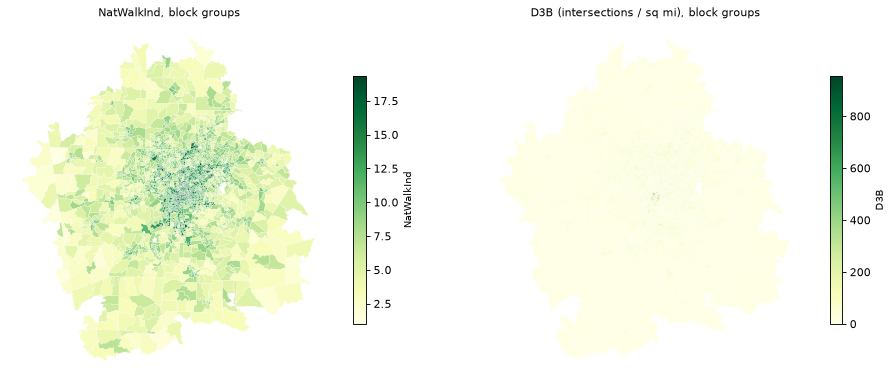

In [ ]:
walkability_gdf = gpd.read_file(RAW_VECTORS / "EPA_walkabilityindex_2025_georgia_blockgroup.gpkg").to_crs(TARGET_CRS)
bg = walkability_gdf[walkability_gdf.intersects(zipcode_gdf.union_all())]
print(f"block groups in Georgia: {len(walkability_gdf)}, intersecting the study ZIPs: {len(bg)}")
print(f"D4A == -99999 (sentinel) in these block groups: {(bg['D4A'] == -99999).sum()}")

sanity_report(bg, ["NatWalkInd", "D3B", "TotPop", "CountHU"])
assert bg[["NatWalkInd", "D3B"]].notna().all().all() and (bg[["NatWalkInd", "D3B"]] >= 0).all().all()
plot_choropleths(bg, ["NatWalkInd", "D3B"], ["NatWalkInd, block groups", "D3B (intersections / sq mi), block groups"], cmap="YlGn")

NatWalkInd_zip    190
D3B_zip           190
block-group coverage of ZIP area: min 1.0000, max 1.0000; ZIPs < 0.95: 0


,n,n_null,pct_null,min,p25,median,p75,max,n_zero,n_negative
NatWalkInd_zip,190,0,0.0,3.034675,5.025471,6.768388,9.954102,16.341808,0,0
D3B_zip,190,0,0.0,1.118265,6.165279,24.111812,51.125420,309.106475,0,0


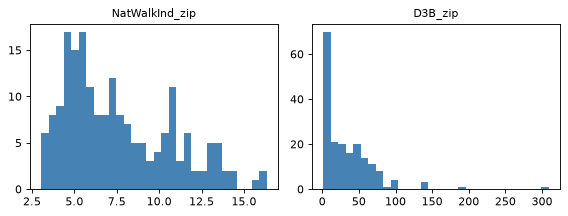

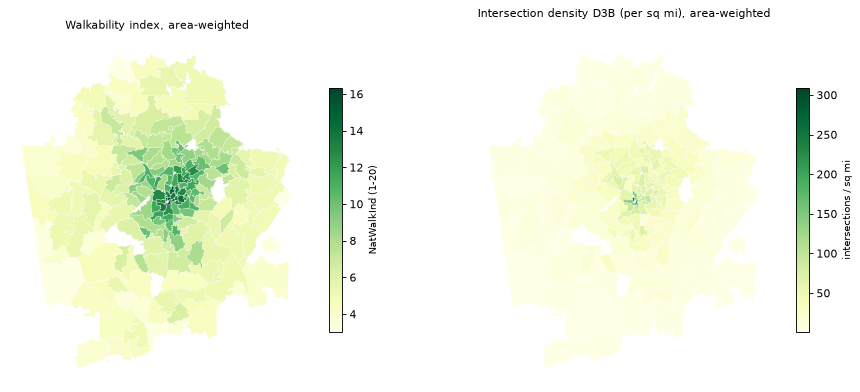

In [ ]:
pieces = gpd.overlay(zipcode_gdf[["ZIP5", "geometry"]], bg[["NatWalkInd", "D3B", "geometry"]], how="intersection", keep_geom_type=True)
pieces["w"] = pieces.area
sums = pieces.assign(NatWalkInd_zip=pieces["NatWalkInd"] * pieces["w"], D3B_zip=pieces["D3B"] * pieces["w"]).groupby("ZIP5")
zipcode_gdf = join_zip(zipcode_gdf, sums[["NatWalkInd_zip", "D3B_zip"]].sum().div(sums["w"].sum(), axis=0))

coverage = sums["w"].sum() / zipcode_gdf.set_index("ZIP5")["zip_area_sqft"]
print(f"block-group coverage of ZIP area: min {coverage.min():.4f}, max {coverage.max():.4f}; ZIPs < 0.95: {(coverage < 0.95).sum()}")

sanity_report(zipcode_gdf, ["NatWalkInd_zip", "D3B_zip"])
assert zipcode_gdf["NatWalkInd_zip"].between(1, 20).all() and zipcode_gdf["D3B_zip"].between(bg["D3B"].min(), bg["D3B"].max()).all()
plot_choropleths(zipcode_gdf, ["NatWalkInd_zip", "D3B_zip"],
                 ["Walkability index, area-weighted", "Intersection density D3B (per sq mi), area-weighted"],
                 legend_labels=["NatWalkInd (1-20)", "intersections / sq mi"], cmap="YlGn")

## 7. Microsoft building footprints

**Data.** `georgia_building_length_microsoft.gpkg`: Microsoft US Building Footprints for Georgia, about
4 million polygons in EPSG:4326. The file was converted from the ~1 GB GeoJSON with `ogr2ogr`
(methodology §2). The imagery dates from **2018–2020**.

**Method.**
- Footprint area is computed in sq ft (EPSG:2240).
- Each building is assigned to the ZIP containing its **representative point**, so a building on a ZIP
  boundary is counted exactly once. An *Intersects* join would count it in both ZIPs.
- Buildings are first cut to the study bounding box (`.cx`), to avoid a point-in-polygon test on all
  4 million.

**Outputs.**
- `ms_bldg_count`
- `ms_sum_area_sqft`, `ms_mean_area_sqft`, `ms_max_area_sqft`
- `ms_bldg_coverage_ratio` = `ms_sum_area_sqft` / `zip_area_sqft`

**Caveats.**
- **Vintage.** An ArcGIS QC against the 2012 City of Atlanta footprints found Microsoft's tract totals a
  median **+13.7%** higher (IQR +3.5% to +27.5%; methodology §2). Treat these metrics as slightly inflated
  relative to 2011.
- Footprints are 2-D outlines. They record neither height nor use.
- The coverage denominator includes water.
- Very small (< 100 sq ft) and very large (> 500,000 sq ft) footprints are counted but kept, because
  they are real features of the published product.

**Sanity check.** Every ZIP should have buildings, and every coverage ratio must lie strictly between 0
and 1.

buildings in Georgia: 3,981,792; in the study bounding box: 2,254,341; assigned to a study ZIP: 1,846,537 (81.9%)
tiny footprints (< 100 sq ft): 19; huge footprints (> 500,000 sq ft): 147


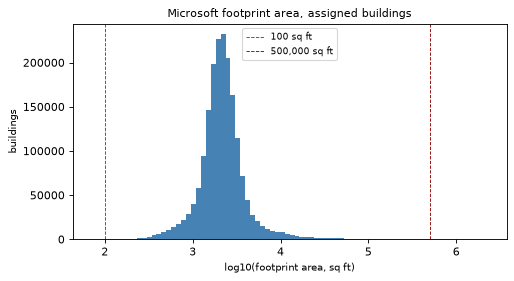

In [ ]:
ms_buildings_gdf = gpd.read_file(RAW_VECTORS / "georgia_building_length_microsoft.gpkg").to_crs(TARGET_CRS)
minx, miny, maxx, maxy = zipcode_gdf.total_bounds
bldg = ms_buildings_gdf.cx[minx:maxx, miny:maxy][["geometry"]]
bldg = gpd.GeoDataFrame({"bldg_area_sqft": bldg.area}, geometry=bldg.representative_point(), crs=TARGET_CRS)
n_bbox = len(bldg)
bldg = gpd.sjoin(bldg, zipcode_gdf[["ZIP5", "geometry"]], predicate="within")
print(f"buildings in Georgia: {len(ms_buildings_gdf):,}; in the study bounding box: {n_bbox:,}; "
      f"assigned to a study ZIP: {len(bldg):,} ({len(bldg) / n_bbox:.1%})")

area = bldg["bldg_area_sqft"]
print(f"tiny footprints (< 100 sq ft): {(area < 100).sum():,}; huge footprints (> 500,000 sq ft): {(area > 500_000).sum():,}")
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(np.log10(area), bins=80, color="steelblue")
for v, c in [(100, "red"), (500_000, "darkred")]:
    ax.axvline(np.log10(v), color=c, linestyle="--", linewidth=0.8, label=f"{v:,} sq ft")
ax.set(title="Microsoft footprint area, assigned buildings", xlabel="log10(footprint area, sq ft)", ylabel="buildings")
ax.legend(fontsize=8)
plt.show()

ms_bldg_count             190
ms_sum_area_sqft          190
ms_mean_area_sqft         190
ms_max_area_sqft          190
ms_bldg_coverage_ratio    190


,n,n_null,pct_null,min,p25,median,p75,max,n_zero,n_negative
ms_bldg_count,190,0,0.0,296.000000,4.159000e+03,8.463000e+03,1.384975e+04,2.726600e+04,0,0
ms_sum_area_sqft,190,0,0.0,473525.825812,1.375709e+07,2.759039e+07,4.256956e+07,9.452718e+07,0,0
ms_mean_area_sqft,190,0,0.0,1599.749412,2.529397e+03,2.865186e+03,3.507504e+03,1.344253e+04,0,0
ms_max_area_sqft,190,0,0.0,13085.881649,1.837161e+05,2.677326e+05,5.598099e+05,2.232392e+06,0,0
ms_bldg_coverage_ratio,190,0,0.0,0.001559,9.137496e-03,4.646704e-02,8.698825e-02,2.480438e-01,0,0


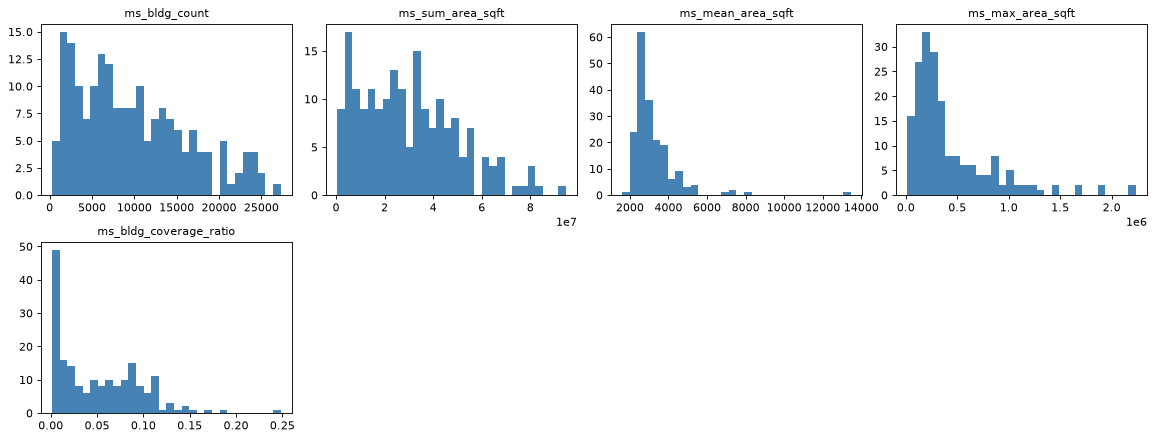

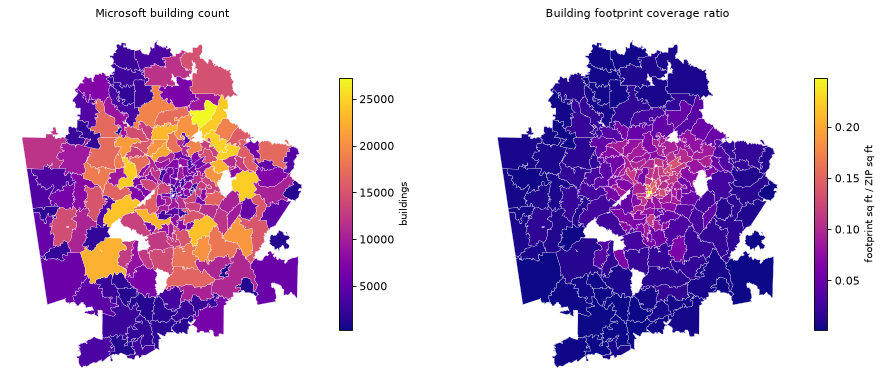

In [ ]:
bldg_vars = bldg.groupby("ZIP5")["bldg_area_sqft"].agg(
    ms_bldg_count="count", ms_sum_area_sqft="sum", ms_mean_area_sqft="mean", ms_max_area_sqft="max")
bldg_vars["ms_bldg_coverage_ratio"] = bldg_vars["ms_sum_area_sqft"] / zipcode_gdf.set_index("ZIP5")["zip_area_sqft"]
MS_COLS = list(bldg_vars.columns)
zipcode_gdf = join_zip(zipcode_gdf, bldg_vars)

sanity_report(zipcode_gdf, MS_COLS)
assert zipcode_gdf[MS_COLS].notna().all().all() and zipcode_gdf["ms_bldg_coverage_ratio"].between(0, 1, inclusive="neither").all()
plot_choropleths(zipcode_gdf, ["ms_bldg_count", "ms_bldg_coverage_ratio"], ["Microsoft building count", "Building footprint coverage ratio"],
                 legend_labels=["buildings", "footprint sq ft / ZIP sq ft"], cmap="plasma")

## 8. Socioeconomic variables (2011 ACS/Census, ZIP level)

### 8.1 Data

The source is `May_Zip_Tract_regular_June_2.xlsx`, provided with the study data. It has two sheets.

**`Full_data_transpose_IV`** has no header row. Each row is one geography:
- rows with `Georgraphy` (column 360) = 1 are **209 ZIPs**;
- rows with `Georgraphy` = 2 are **1,969 Census tracts**.

Column 357 holds the ID (a 5-character ZIP or an 11-character tract GEOID), and columns 358/359 hold
lat/lon.

**`Sheet2`** is the codebook. Row *i* gives the label (column 0) and variable number (column 1) of data
column *i*. Column 0 of the data is `Residential Energy KWh/yr`. Columns 1–356 are ACS/Census
variables and derived ratios.

In [ ]:
SE_XLSX = RAW_TABLES / "May_Zip_Tract_regular_June_2.xlsx"
ID_COL, GEO_COL = 357, 360
se_raw = pd.read_excel(SE_XLSX, sheet_name="Full_data_transpose_IV", header=None, dtype={ID_COL: str})
codebook_raw = pd.read_excel(SE_XLSX, sheet_name="Sheet2", header=None)
assert len(codebook_raw) == se_raw.shape[1]
se_raw[GEO_COL].value_counts().rename("rows")

360
2    1969
1     209
Name: rows, dtype: int64

### 8.2 Why not the earlier ArcGIS CSV

`data/raw/tables/zip_energy_socioeconomic_arcgis_ready.csv` is an earlier ArcGIS export of the same
workbook. It is kept in `raw` for provenance but **not used**, for three reasons (evidence below):

- only 39 ZIP rows survived the export;
- its residential energy column (`RESIENER`) no longer matches the source;
- its field names are truncated to 10 characters, which makes them ambiguous.

In [ ]:
arc = pd.read_csv(RAW_TABLES / "zip_energy_socioeconomic_arcgis_ready.csv", dtype=str)
arc_zip = arc[arc["Zipcode"].str.len() == 5].set_index("Zipcode")
src_zip = se_raw[se_raw[GEO_COL] == 1].set_index(ID_COL)
pd.DataFrame(
    {"arcgis_ready.csv": [len(arc_zip), zipcode_gdf["ZIP5"].isin(arc_zip.index).sum(), f"{float(arc_zip.loc['30303', 'RESIENER']):,.0f}", max(map(len, arc.columns))],
     "source workbook": [len(src_zip), zipcode_gdf["ZIP5"].isin(src_zip.index).sum(), f"{src_zip.loc['30303', 0]:,.0f}", codebook_raw[0].str.len().max()]},
    index=["ZIP rows", "study ZIPs present (of 190)", "residential energy, ZIP 30303", "longest variable name / label (chars)"],
)

,arcgis_ready.csv,source workbook
ZIP rows,39,209
study ZIPs present (of 190),32,190
"residential energy, ZIP 30303","132,261","23,830,302"
longest variable name / label (chars),10,198


### 8.3 Codebook

- Each data column gets a stable code: `se_v{number:03d}`, or `se_resid_energy_kwh` for column 0.
- Seven labels are duplicated in `Sheet2`. Each repeat gets a ` [dup k]` suffix, so every label is
  unique.
- `in_highEE_model` / `in_lowEE_model` flag the predictors of each cluster model. The predictors are
  the column names of the `highET_Og` sheet in each model workbook, minus `Energy`, matched after
  normalising whitespace.

The codebook is saved to `data/interim/socioeconomic_codebook.csv`.

In [ ]:
def norm_label(s):
    return re.sub(r"\s+", " ", str(s)).strip()


codebook = pd.DataFrame({"col_idx": range(len(codebook_raw)), "var_number": codebook_raw[1].astype(str).str.strip(),
                         "label_raw": codebook_raw[0].astype(str).str.strip()})
assert (codebook["var_number"][1:].astype(int) == codebook["col_idx"][1:]).all()
codebook["se_code"] = ["se_resid_energy_kwh"] + [f"se_v{n:03d}" for n in codebook["col_idx"][1:]]
codebook["role"] = np.select([codebook["col_idx"] == 0, codebook["col_idx"] >= ID_COL],
                             ["target (duplicates energy_actual_kwh)", "metadata"], "variable")
k = codebook.groupby("label_raw").cumcount() + 1
codebook["label"] = codebook["label_raw"].where(k == 1, codebook["label_raw"] + " [dup " + k.astype(str) + "]")
assert codebook["label"].is_unique

label_norm = codebook["label_raw"].map(norm_label)
MODEL_PREDICTORS = {}
for label, (fname, _) in MODEL_WORKBOOKS.items():
    preds = [c for c in pd.read_excel(RAW_TABLES / fname, sheet_name="highET_Og", nrows=0).columns if c != "Energy"]
    MODEL_PREDICTORS[label] = preds
    codebook[f"in_{label.lower()}EE_model"] = label_norm.isin({norm_label(p) for p in preds})
    print(f"{fname}: {len(preds)} predictors; unmatched labels: {[p for p in preds if norm_label(p) not in set(label_norm)]}")

codebook.to_csv(INTERIM / "socioeconomic_codebook.csv", index=False)
display(codebook.loc[codebook["label_raw"].duplicated(keep=False), ["se_code", "label"]])

highEE_FullData.xlsx: 18 predictors; unmatched labels: []
lowEE_FullData.xlsx: 35 predictors; unmatched labels: []


,se_code,label
60,se_v060,Number; HOUSING OCCUPANCY - Total housing unit...
63,se_v063,Number; HOUSING OCCUPANCY - Total housing unit...
175,se_v175,Percent; INCOME AND BENEFITS (IN 2011 INFLATIO...
176,se_v176,Percent; INCOME AND BENEFITS (IN 2011 INFLATIO...
177,se_v177,Percent; INCOME AND BENEFITS (IN 2011 INFLATIO...
180,se_v180,Percent; INCOME AND BENEFITS (IN 2011 INFLATIO...
181,se_v181,Percent; INCOME AND BENEFITS (IN 2011 INFLATIO...
182,se_v182,Percent; INCOME AND BENEFITS (IN 2011 INFLATIO...
346,se_v346,"Estimate; INCOME AND BENEFITS (IN 2011-(dol, a..."
347,se_v347,"Estimate; INCOME AND BENEFITS (IN 2011-(dol, a..."


### 8.4 Cleaning rules

Every cell becomes a number. Text cells follow these rules:

- **Placeholders → NaN:** `-`, `N`, `\` and `(X)` (ACS "no estimate" / "not applicable").
- **Censored values → their bound:** `1939-` and `2005+` (median year built), `2,000+` (rent) and
  similar. The trailing `+`/`-` and the thousands separators are stripped. The true value lies beyond
  the bound, so treat these as censored.
- **Anything else → NaN, counted in the table below.** There are none in the ZIP rows. The tract rows
  contain a few dozen annotated cells such as `710(r2968)`. Their meaning is unknown, so review them
  before the tract-level work.

The ZIP rows are keyed `ZIP5`, and the tract rows `TractGeoID` (text, zero-padded to 11 characters).
The tract rows are saved to `data/interim/socioeconomic_tract.csv`.

In [ ]:
PLACEHOLDERS = {"-", "N", "\\", "(X)"}
NUMBER_TEXT = r"(\d[\d,]*(?:\.\d+)?)[+-]?"  # "2005+", "1939-", "2,000+"


def parse_cell(v):
    if not isinstance(v, str):
        return v
    m = re.fullmatch(NUMBER_TEXT, v.strip())
    return float(m.group(1).replace(",", "")) if m else np.nan


values = se_raw.iloc[:, :ID_COL]
text = values.stack()
text = text[text.map(lambda v: isinstance(v, str))].str.strip()
rule = np.select([text.isin(PLACEHOLDERS), text.str.fullmatch(NUMBER_TEXT)], ["placeholder -> NaN", "censored -> bound"], "other -> NaN")
display(pd.crosstab(rule, se_raw[GEO_COL].loc[text.index.get_level_values(0)].map({1: "ZIP rows", 2: "tract rows"}).to_numpy()))
assert not ((rule == "other -> NaN") & (se_raw[GEO_COL].loc[text.index.get_level_values(0)] == 1).to_numpy()).any()

se = values.map(parse_cell).astype("float64").set_axis(list(codebook["se_code"][:ID_COL]), axis=1)
ids = se_raw[ID_COL].str.strip()
se_zip = se[se_raw[GEO_COL] == 1].set_axis(ids[se_raw[GEO_COL] == 1].str.zfill(5).rename("ZIP5"))
se_tract = se[se_raw[GEO_COL] == 2].set_axis(ids[se_raw[GEO_COL] == 2].str.zfill(11).rename("TractGeoID"))
assert len(se_zip) == 209 and se_zip.index.is_unique and (se_zip.index.str.len() == 5).all()
assert len(se_tract) == 1969 and se_tract.index.is_unique and (se_tract.index.str.len() == 11).all()
se_tract.to_csv(INTERIM / "socioeconomic_tract.csv")

col_0,ZIP rows,tract rows
row_0,,
censored -> bound,3,94
other -> NaN,0,48
placeholder -> NaN,106,798


### 8.5 Alignment check

Before joining, the source must reproduce the base layer exactly:

- all 190 study ZIPs are present;
- `se_resid_energy_kwh` equals `energy_actual_kwh`;
- total population (`se_v001`) equals `pop`.

In [ ]:
assert zipcode_gdf["ZIP5"].isin(se_zip.index).all()
aligned = se_zip.loc[zipcode_gdf["ZIP5"]]
assert np.isclose(aligned["se_resid_energy_kwh"], zipcode_gdf["energy_actual_kwh"]).all()
assert codebook.loc[1, "label_raw"] == "Number; SEX AND AGE - Total population"
assert np.isclose(aligned["se_v001"], zipcode_gdf["pop"]).all()
print("alignment OK: 190/190 ZIPs present; energy and total population match")

alignment OK: 190/190 ZIPs present; energy and total population match


### 8.6 Join

The join is a direct one-to-one match on `ZIP5`. No aggregation is needed, because both tables are at
ZIP level. `se_resid_energy_kwh` is left out because it duplicates `energy_actual_kwh`.

**EDA.**
- A missing-value count.
- Six key variables, mapped and summarised. They are looked up by codebook label, and each lookup must
  match.
- The predictors of each cluster model.

**Population density** appears twice in the codebook. The copy used here, `se_v354`, is the one that
equals total population / area (`se_v355` / `se_v353`, persons per sq mi); the code checks this.

**Caveats.**
- The source is a compilation of 2011 ACS/Census data. Whether it uses the 5-year or 1-year ACS is to
  be confirmed.
- Several variables are derived ratios whose formulas are known only from their labels.

SE variables joined: 356; ZIPs matched: 190/190; missing values among them: 0


,se_code,label
Total population,se_v001,Number; SEX AND AGE - Total population
Median household income ($),se_v178,Estimate; INCOME AND BENEFITS (IN 2011 INFLATI...
Median home value ($),se_v161,Estimate; VALUE - Median (dollars)
Population density (persons / sq mi),se_v354,Population density [dup 2]
Median year structure built,se_v352,Estimate; Median year structure built
% commuting by public transit,se_v172,Percent; COMMUTING TO WORK - Public transporta...


,n,n_null,pct_null,min,p25,median,p75,max,n_zero,n_negative
se_v001,190,0,0.0,730.0000,11973.75000,25227.000000,38023.000000,80241.00000,0,0
se_v178,190,0,0.0,22400.0000,44165.00000,52360.000000,66910.500000,130270.00000,0,0
se_v161,190,0,0.0,81100.0000,134225.00000,160800.000000,210775.000000,774900.00000,0,0
se_v354,190,0,0.0,25.2625,207.95883,987.741484,2408.565509,9688.77551,0,0
se_v352,190,0,0.0,1950.0000,1980.00000,1987.000000,1993.000000,2002.00000,0,0
se_v172,190,0,0.0,0.0000,0.40000,0.950000,3.550000,25.20000,30,0


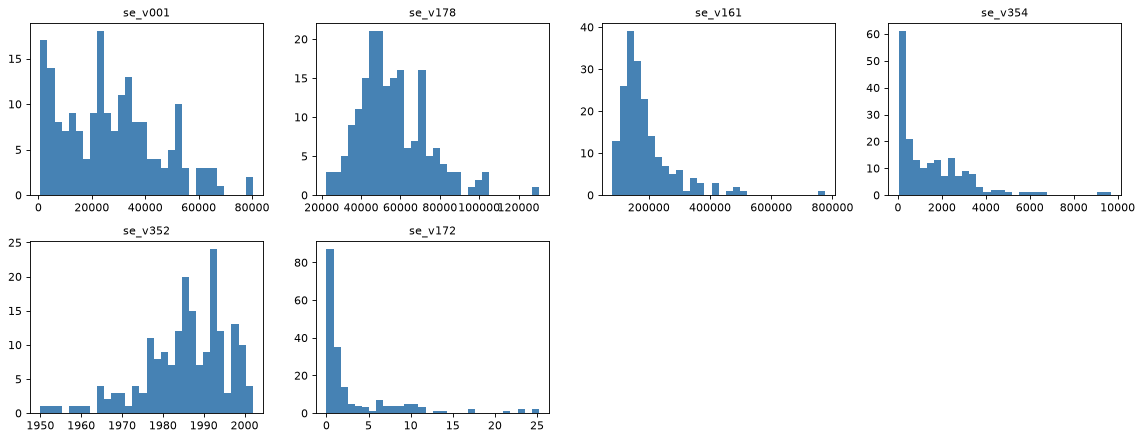

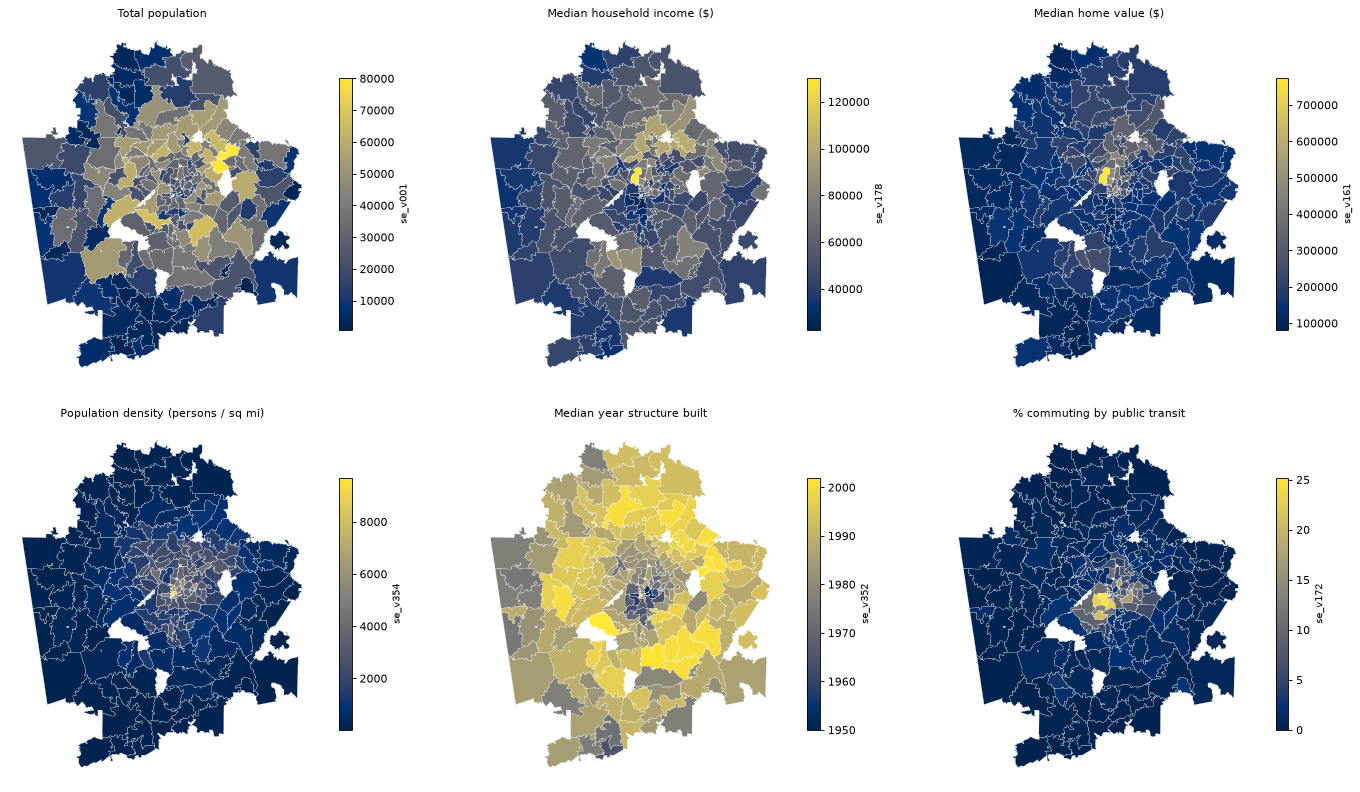

,model,predictor_label,se_code
0,HIGH cluster,Percent; EMPLOYMENT STATUS - All parents in family in labor force pop over 16,se_v169
1,HIGH cluster,Number; SEX AND AGE - Male population - 62 years and over,se_v014
2,HIGH cluster,Number; SEX AND AGE - Total population,se_v001
3,HIGH cluster,100*Number of rent occupied house units with >= 1 vehicle/Total rent occupied Housing units,se_v214
4,HIGH cluster,Pop 5 to 24,se_v002
5,HIGH cluster,100*White Occupied Owned Housing Units/Tot Number of Owned Occupied Housing Units,se_v072
6,HIGH cluster,Tot Female_Male Ratio High school Diploma,se_v307
7,HIGH cluster,Number; SEX AND AGE - Male population,se_v009
8,HIGH cluster,Number of Housing Units Built 1970 to 1979 or later/Total Housing Units,se_v275
9,HIGH cluster,100*Owner occupied: - 7-or-more-person household/Total Owner Ocuppied House units,se_v100


In [ ]:
SE_COLS = list(codebook.loc[codebook["role"] == "variable", "se_code"])
zipcode_gdf = zipcode_gdf.join(se_zip[SE_COLS], on="ZIP5", validate="one_to_one")
print(f"SE variables joined: {len(SE_COLS)}; ZIPs matched: {zipcode_gdf[SE_COLS].notna().any(axis=1).sum()}/190; "
      f"missing values among them: {zipcode_gdf[SE_COLS].isna().sum().sum()}")


def find_se(label, exact=False):
    """se_code of the first codebook variable whose label contains (or equals) `label`."""
    lab = codebook["label_raw"]
    hits = codebook[(lab == label if exact else lab.str.contains(label, regex=False)) & (codebook["role"] == "variable")]
    assert len(hits) > 0, f"no codebook label matches {label!r}"
    return hits["se_code"].iloc[0]


assert codebook.loc[354, "label_raw"] == "Population density"
assert np.allclose(se_zip["se_v354"], se_zip["se_v355"] / se_zip["se_v353"], equal_nan=True)
KEY_SE = {
    "Total population": find_se("Number; SEX AND AGE - Total population", exact=True),
    "Median household income ($)": find_se("Median household income"),
    "Median home value ($)": find_se("VALUE - Median"),
    "Population density (persons / sq mi)": "se_v354",
    "Median year structure built": find_se("Median year structure built"),
    "% commuting by public transit": find_se("Public transportation"),
}
display(pd.DataFrame({"se_code": KEY_SE}).join(codebook.set_index("se_code")["label"], on="se_code"))

sanity_report(zipcode_gdf, list(KEY_SE.values()))
assert zipcode_gdf[KEY_SE["% commuting by public transit"]].between(0, 100).all()
assert zipcode_gdf[KEY_SE["Median year structure built"]].between(1939, 2011).all()
plot_choropleths(zipcode_gdf, list(KEY_SE.values()), list(KEY_SE.keys()), ncols=3, cmap="cividis")

code_of = dict(zip(label_norm[::-1], codebook["se_code"][::-1]))  # first match wins
with pd.option_context("display.max_colwidth", 120, "display.max_rows", 100):
    display(pd.DataFrame([(f"{k} cluster", p, code_of.get(norm_label(p))) for k, v in MODEL_PREDICTORS.items() for p in v],
                         columns=["model", "predictor_label", "se_code"]))

## 9. Land use (ARC LandPro 2012)

**Data.** `LandPro_2012.shp`: the Atlanta Regional Commission's 2012 land-use / land-cover polygons,
public open data. It has 54,162 polygons and is already in EPSG:2240. Two fields are used:
- `LU_NAME`: 29 land-use classes (e.g. `RES_LOW`, `COMMERCIAL`, `FOREST`, `IND/COM`);
- `DE3`: a three-way grouping of those classes into `DEVELOPED`, `UNDEVELOPED` and `UNDEVELOPABLE`.

**Method.**
- About 0.7% of the geometries are invalid (self-intersections). They are repaired with `make_valid()`,
  and only the polygonal parts are kept. Without the repair, the overlay fails with a
  `TopologyException`.
- ZIPs and LandPro polygons are intersected (`gpd.overlay`), and the area of each piece is computed in
  sq ft.
- **`landpro_coverage_frac`** = LandPro area inside the ZIP / `zip_area_sqft`. It is kept for all
  190 ZIPs.
- **`lu_pct_<class>`** is the share of each of the 29 `LU_NAME` classes, and **`lu_pct_developed`**,
  **`lu_pct_undeveloped`** and **`lu_pct_undevelopable`** the shares of the `DE3` groups, all as a
  **percent of the covered area**. Class names are lower-cased, and `/` becomes `_` (`IND/COM` →
  `lu_pct_ind_com`). A class absent from a ZIP gets 0.
- **Shares are set to NaN unless `landpro_coverage_frac` ≥ 0.99.** A share computed on a small covered
  fraction describes only the part of the ZIP inside the ARC region, not the ZIP, so it is withheld
  rather than extrapolated.

**Caveats.**
- **LandPro covers only the ARC region** (the metro counties). ZIPs on the edge of the study area are
  partly or wholly outside it, and they are all LOW-cluster ZIPs, so land-use analyses cover all HIGH
  ZIPs but only part of the LOW cluster.
- The land-use classes are interpreted from 2012 imagery and parcel data. Class boundaries are
  approximate.
- `DE3` is almost, but not strictly, nested within `LU_NAME`: four small `CHURCH` / `COMMERCIAL`
  polygons carry a different group from the rest of their class (table below). The `DE3` shares are
  therefore computed from the `DE3` field itself.
- The covered area includes water (`RESERVOIRS`, `RIVERS`), like the other area denominators.

**Sanity check.**
- The 29 class shares, and the three `DE3` shares, must each sum to 100% (±0.5) for covered ZIPs.
- Coverage must not exceed 1 (tolerance 0.001). Coverage above 1 would reveal overlapping LandPro
  polygons.

In [ ]:
landpro_gdf = gpd.read_file(RAW_VECTORS / "LandPro_2012.shp").to_crs(TARGET_CRS)
n_polygons, n_invalid = len(landpro_gdf), (~landpro_gdf.is_valid).sum()
display(landpro_gdf.groupby(["DE3", "LU_NAME"]).agg(polygons=("ACRES", "size"), acres=("ACRES", "sum")).round(0))

landpro_gdf["geometry"] = landpro_gdf.make_valid()
landpro_gdf = landpro_gdf.explode(index_parts=False)
landpro_gdf = landpro_gdf[landpro_gdf.geom_type == "Polygon"]
assert landpro_gdf.is_valid.all()
print(f"LandPro polygons: {n_polygons:,}; invalid, repaired with make_valid: {n_invalid} ({n_invalid / n_polygons:.1%}); "
      f"polygonal parts kept: {len(landpro_gdf):,}")

LU_CLASSES = sorted(landpro_gdf["LU_NAME"].unique())
DE3_GROUPS = ["DEVELOPED", "UNDEVELOPED", "UNDEVELOPABLE"]
assert len(LU_CLASSES) == 29 and set(landpro_gdf["DE3"]) == set(DE3_GROUPS)

polygons      acres
DE3           LU_NAME                            
DEVELOPED     AIRPORT               41     9080.0
              CHURCH              3770    20953.0
              COMMERCIAL          4190   135267.0
              CST                 1998    36297.0
              IND/COM              463    60687.0
              INDUSTRIAL           170     8228.0
              INST_INTENSIVE      1735    46599.0
              RES_HIGH            1989    72798.0
              RES_LOW             6941   574448.0
              RES_MED             4143   630568.0
              RES_MOBILE           302     7103.0
              RES_MULTI           2320    56558.0
              TCU                  270    11481.0
UNDEVELOPABLE CEMETERIES           945     5783.0
              CHURCH                 1        2.0
              COMMERCIAL             2        9.0
              EXPOSED_ROCK         119     1490.0
              GOLF_COURSES         370    29284.0
              INST_EXTENSIVE       760    46357.0
              LTD_ACCESS            14    23698.0
              PARKS                742    20486.0
              PARK_LAND           1236   146977.0
              QUARRIES              42     9691.0
              RESERVOIRS          2243    84260.0
              RIVERS                 6     4769.0
              WETLANDS            1299    85613.0
UNDEVELOPED   AGRICULTURE         4159   678602.0
              CHURCH                 1        4.0
              FOREST              9893  1319028.0
              LANDFILLS             59     7129.0
              TRANSITIONAL        3104    84250.0
              URBAN_OTHER          835    17449.0

LandPro polygons: 54,162; invalid, repaired with make_valid: 363 (0.7%); polygonal parts kept: 54,188


In [ ]:
pieces = gpd.overlay(zipcode_gdf[["ZIP5", "geometry"]], landpro_gdf[["LU_NAME", "DE3", "geometry"]], how="intersection", keep_geom_type=True)
pieces["w"] = pieces.area
lu_area = pieces.pivot_table(index="ZIP5", columns="LU_NAME", values="w", aggfunc="sum", fill_value=0).reindex(columns=LU_CLASSES, fill_value=0)
de3_area = pieces.pivot_table(index="ZIP5", columns="DE3", values="w", aggfunc="sum", fill_value=0).reindex(columns=DE3_GROUPS, fill_value=0)
covered = lu_area.sum(axis=1)

LU_DE3_COLS = ["lu_pct_" + g.lower() for g in DE3_GROUPS]
LU_CLASS_COLS = ["lu_pct_" + c.lower().replace("/", "_") for c in LU_CLASSES]
LU_COLS = LU_DE3_COLS + LU_CLASS_COLS
assert all(re.fullmatch(r"[a-z0-9_]+", c) for c in LU_COLS)

zip_area = zipcode_gdf.set_index("ZIP5")["zip_area_sqft"]
landuse = pd.concat([de3_area.set_axis(LU_DE3_COLS, axis=1), lu_area.set_axis(LU_CLASS_COLS, axis=1)], axis=1).div(covered, axis=0) * 100
landuse.insert(0, "landpro_coverage_frac", covered / zip_area)
landuse = landuse.reindex(zip_area.index)
landuse["landpro_coverage_frac"] = landuse["landpro_coverage_frac"].fillna(0)
landuse.loc[landuse["landpro_coverage_frac"] < 0.99, LU_COLS] = np.nan
zipcode_gdf = join_zip(zipcode_gdf, landuse)

landpro_coverage_frac    190
lu_pct_developed         142
lu_pct_undeveloped       142
lu_pct_undevelopable     142
lu_pct_agriculture       142
lu_pct_airport           142
lu_pct_cemeteries        142
lu_pct_church            142
lu_pct_commercial        142
lu_pct_cst               142
lu_pct_exposed_rock      142
lu_pct_forest            142
lu_pct_golf_courses      142
lu_pct_ind_com           142
lu_pct_industrial        142
lu_pct_inst_extensive    142
lu_pct_inst_intensive    142
lu_pct_landfills         142
lu_pct_ltd_access        142
lu_pct_parks             142
lu_pct_park_land         142
lu_pct_quarries          142
lu_pct_reservoirs        142
lu_pct_res_high          142
lu_pct_res_low           142
lu_pct_res_med           142
lu_pct_res_mobile        142
lu_pct_res_multi         142
lu_pct_rivers            142
lu_pct_tcu               142
lu_pct_transitional      142
lu_pct_urban_other       142
lu_pct_wetlands          142


cluster,HIGH,LOW,All
LandPro coverage,,,
>= 0.99 (shares kept),63,79,142
0.5 to 0.99,0,17,17
0 to 0.5,0,14,14
0 (outside ARC region),0,17,17
All,63,127,190


max coverage: 1.000000; ZIPs with coverage > 1.0001 (overlapping LandPro polygons): 0


,n,n_null,pct_null,min,p25,median,p75,max,n_zero,n_negative
landpro_coverage_frac,190,0,0.0,0.000000,0.972380,1.000000,1.000000,1.000000,17,0
lu_pct_developed,142,48,25.3,13.404988,46.895170,69.104241,83.079202,95.551359,0,0
lu_pct_undeveloped,142,48,25.3,0.331477,6.910134,15.817868,41.162190,81.394323,0,0
lu_pct_undevelopable,142,48,25.3,2.192488,5.758308,8.797316,12.742305,33.739826,0,0


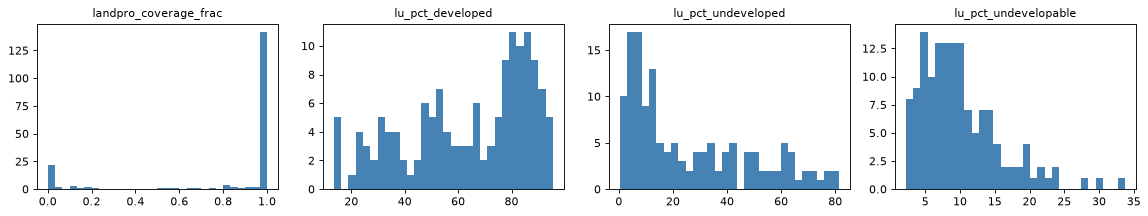

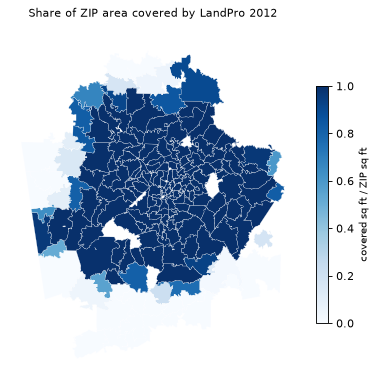

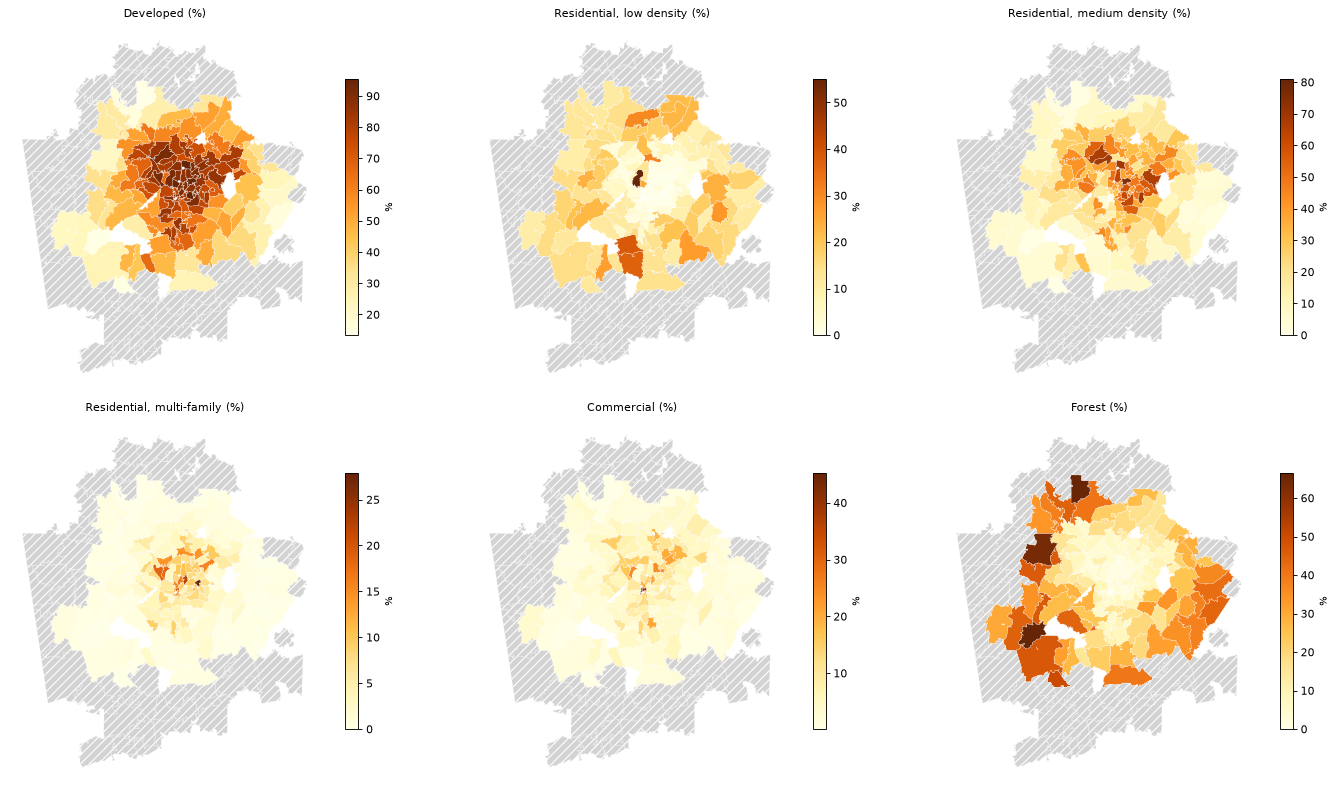

,all covered ZIPs,HIGH,LOW
mean share (%),,,
lu_pct_developed,63.78,74.63,55.14
lu_pct_undeveloped,26.18,15.19,34.94
lu_pct_undevelopable,10.04,10.18,9.92
lu_pct_agriculture,6.63,2.30,10.09
lu_pct_airport,0.49,0.14,0.76
lu_pct_cemeteries,0.26,0.36,0.18
lu_pct_church,0.90,1.14,0.71
lu_pct_commercial,7.03,8.90,5.53
lu_pct_cst,0.83,0.95,0.73


In [ ]:
cov = zipcode_gdf["landpro_coverage_frac"]
band = pd.Categorical(np.select([cov >= 0.99, cov >= 0.5, cov > 0], [">= 0.99 (shares kept)", "0.5 to 0.99", "0 to 0.5"], "0 (outside ARC region)"),
                      categories=[">= 0.99 (shares kept)", "0.5 to 0.99", "0 to 0.5", "0 (outside ARC region)"], ordered=True)
display(pd.crosstab(band, zipcode_gdf["cluster"], margins=True, rownames=["LandPro coverage"]))
covered_zips = cov >= 0.99
assert covered_zips.sum() == 142

# Overlap check: the pieces of a ZIP sum to more than its area only if LandPro polygons overlap.
print(f"max coverage: {cov.max():.6f}; ZIPs with coverage > 1.0001 (overlapping LandPro polygons): {(cov > 1.0001).sum()}")
assert cov.max() <= 1.001
assert np.allclose(zipcode_gdf.loc[covered_zips, LU_CLASS_COLS].sum(axis=1), 100, atol=0.5)
assert np.allclose(zipcode_gdf.loc[covered_zips, LU_DE3_COLS].sum(axis=1), 100, atol=0.5)

sanity_report(zipcode_gdf, ["landpro_coverage_frac"] + LU_DE3_COLS)
plot_choropleth(zipcode_gdf, "landpro_coverage_frac", "Share of ZIP area covered by LandPro 2012", cmap="Blues", legend_label="covered sq ft / ZIP sq ft")
plt.show()

LU_MAP = {"lu_pct_developed": "Developed (%)", "lu_pct_res_low": "Residential, low density (%)", "lu_pct_res_med": "Residential, medium density (%)",
          "lu_pct_res_multi": "Residential, multi-family (%)", "lu_pct_commercial": "Commercial (%)", "lu_pct_forest": "Forest (%)"}
plot_choropleths(zipcode_gdf, list(LU_MAP), list(LU_MAP.values()), ncols=3, legend_labels=["%"] * len(LU_MAP), cmap="YlOrBr")

with pd.option_context("display.max_rows", 40):
    display(pd.DataFrame({"all covered ZIPs": zipcode_gdf[LU_COLS].mean(), **zipcode_gdf.groupby("cluster")[LU_COLS].mean().T})
            .round(2).rename_axis("mean share (%)"))

### 9.1 Land-use coverage gaps (data request)

- LandPro 2012 covers only the Atlanta Regional Commission (ARC) region, so it does not reach every
  study ZIP.
- The 48 ZIPs with less than 99% coverage are all in the LOW cluster. Their land-use shares
  (`lu_pct_*`) are blank (NaN): 31 are partly covered and 17 have no coverage at all.
- The map shows the coverage status of all 190 ZIPs and labels the 48 gap ZIPs. The table below, saved
  as `data/processed/landuse_coverage_gaps.csv`, lists the ZIPs for which land-use data needs to be
  sourced to fill the gap, sorted by coverage. `missing_area_sqmi` is the ZIP area outside LandPro.
  A few "Partial" ZIPs touch the ARC region only along their edge, so their coverage rounds to 0.0%.
- The lon/lat bounding box (EPSG:4326) of the gap ZIPs is printed at the end, as an extent for
  downloading replacement data.

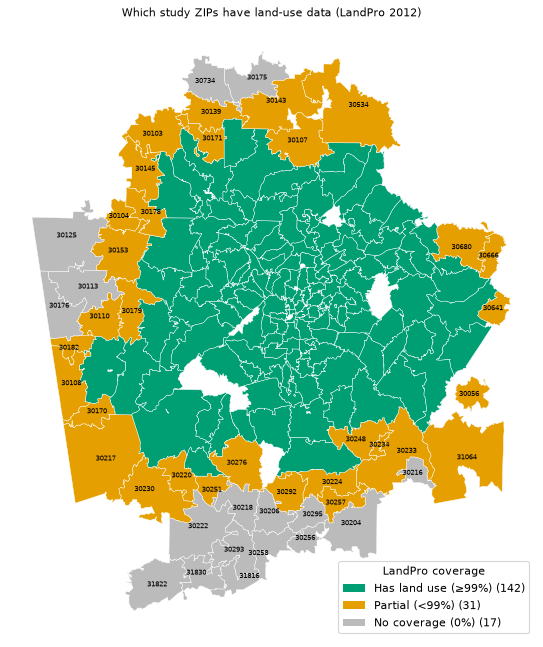

cluster,HIGH,LOW,All
landuse_status,,,
Has land use (≥99%),63,79,142
Partial (<99%),0,31,31
No coverage (0%),0,17,17
All,63,127,190


,ZIP5,cluster,landpro_coverage_pct,missing_area_sqmi,landuse_status
0,30125,LOW,0.0,183.9,No coverage (0%)
1,30175,LOW,0.0,88.2,No coverage (0%)
2,30216,LOW,0.0,30.3,No coverage (0%)
3,30734,LOW,0.0,76.5,No coverage (0%)
4,30218,LOW,0.0,68.3,No coverage (0%)
5,30256,LOW,0.0,34.8,No coverage (0%)
6,30204,LOW,0.0,126.1,No coverage (0%)
7,30258,LOW,0.0,56.8,No coverage (0%)
8,30176,LOW,0.0,83.9,No coverage (0%)
9,31822,LOW,0.0,115.4,No coverage (0%)


Gap ZIPs bounding box (EPSG:4326; min lon, min lat, max lon, max lat): -85.422, 32.772, -83.506, 34.640


In [ ]:
STATUS_COLORS = {"Has land use (≥99%)": "#009E73", "Partial (<99%)": "#E69F00", "No coverage (0%)": "#BBBBBB"}
landuse_status = pd.Series(pd.Categorical(np.select([cov >= 0.99, cov > 0], list(STATUS_COLORS)[:2], "No coverage (0%)"),
                                          categories=list(STATUS_COLORS)), index=zipcode_gdf.index, name="landuse_status")
gap = cov < 0.99

fig, ax = plt.subplots(figsize=(10, 10))
zipcode_gdf.plot(ax=ax, color=landuse_status.map(STATUS_COLORS).astype(str), edgecolor="white", linewidth=0.4)
for zip5, pt in zip(zipcode_gdf.loc[gap, "ZIP5"], zipcode_gdf.loc[gap].representative_point()):
    ax.annotate(zip5, (pt.x, pt.y), ha="center", va="center", fontsize=6)
ax.legend(handles=[Patch(facecolor=c, label=f"{s} ({(landuse_status == s).sum()})") for s, c in STATUS_COLORS.items()],
          loc="lower right", title="LandPro coverage")
ax.set_title("Which study ZIPs have land-use data (LandPro 2012)")
ax.set_axis_off()
plt.show()

display(pd.crosstab(landuse_status, zipcode_gdf["cluster"], margins=True))

gaps = pd.DataFrame({
    "ZIP5": zipcode_gdf["ZIP5"], "cluster": zipcode_gdf["cluster"],
    "landpro_coverage_pct": (cov * 100).round(1),
    "missing_area_sqmi": (zipcode_gdf["zip_area_sqft"] * (1 - cov) / 27_878_400).round(1),
    "landuse_status": landuse_status,
})[gap].loc[cov[gap].sort_values(kind="stable").index].reset_index(drop=True)
with pd.option_context("display.max_rows", 60):
    display(gaps)
gaps.to_csv(PROCESSED / "landuse_coverage_gaps.csv", index=False)

bbox = zipcode_gdf.loc[gap].to_crs(4326).total_bounds.round(3)
print(f"Gap ZIPs bounding box (EPSG:4326; min lon, min lat, max lon, max lat): {', '.join(f'{v:.3f}' for v in bbox)}")
assert len(gaps) == 48 and (gaps["landuse_status"] == "No coverage (0%)").sum() == 17

## 10. Air quality (EPA EQUATES CMAQ v5.3.2, 12 km grid, July 2010)

**Data.** `Daily_EQUATES_CMAQv532_cb6r3_ae7_aq_STAGE_12US1_201007.csv`: EPA EQUATES CMAQ v5.3.2 model
output, public. It holds daily values for every cell of the continental-US 12 km grid (12US1) from
2010-07-01 to 2010-07-31: 816 MB, about 4.25 million rows. Each row gives the cell's `column`/`row`,
its **centre** in lon/lat and in the grid's Lambert Conformal Conic metres (`Lambert_X`,
`LAMBERT_Y`), and 14 pollutant fields:
- **gases, in ppb:** `O3_MDA8` (maximum daily 8-hour average ozone), `O3_AVG`, `CO_AVG`, `NO_AVG`,
  `NO2_AVG`, `SO2_AVG`, `CH2O_AVG` (formaldehyde);
- **particles, in µg/m³:** `PM10_AVG`, `PM25_AVG` and the PM2.5 components `PM25_SO4_AVG`,
  `PM25_NO3_AVG`, `PM25_NH4_AVG`, `PM25_OC_AVG` (organic carbon), `PM25_EC_AVG` (elemental carbon).

Some values are written in Fortran E notation (e.g. `0.400925E-02`), which pandas parses as numbers.

**Method.**
1. **Read in chunks.** The CSV is read 500,000 rows at a time, and only the rows inside the study
   ZIPs' lon/lat bounding box plus 0.5° are kept. This keeps memory use small.
2. **July mean.** Each pollutant is averaged over the 31 days for each cell.
3. **Grid cells as squares.** Each cell is rebuilt as a 12 km square around its centre, in the CMAQ
   Lambert Conformal Conic projection (spherical earth, standard parallels 33° and 45°, origin
   40° N 97° W). The projection is **validated** first: the cell centres, reprojected to lon/lat, must
   match the file's `longitude`/`latitude` to within 0.01°. The squares are then reprojected to
   EPSG:2240.
4. **Area-weighted mean.** ZIPs and cells are intersected (`gpd.overlay`), and each ZIP gets the
   area-weighted mean of the cells it overlaps, as for walkability (Section 6).

**Why area weighting rather than the nearest grid point.** Many ZIPs are larger than a 12 km cell or
straddle two or more cells. The nearest point to a ZIP's centre takes one cell's value and ignores the
rest of the ZIP. Area weighting uses every cell in proportion to how much of the ZIP it covers. The
earlier tract-level methodology used the nearest grid point, so the ZIP values here are not computed the
same way as the tract values.

Columns are named `aq_<field>_jul2010` (e.g. `aq_pm25_avg_jul2010`); units are in the data dictionary.

**Caveats.**
- **One month.** July values describe summer conditions. Ozone in particular is strongly seasonal, so
  these are not annual exposures.
- **Vintage.** 2010, against 2011–2012 for most other layers.
- **Model output, not monitor readings.**
- **12 km resolution.** Neighbouring ZIPs often share the same cells, and so have similar values.
  Contrasts within the urban core are smoothed out.

**Sanity check.**
- Every ZIP must be fully covered by grid cells (coverage ≥ 0.999).
- Every value must be ≥ 0.

In [ ]:
AQ_CSV = RAW_TABLES / "Daily_EQUATES_CMAQv532_cb6r3_ae7_aq_STAGE_12US1_201007.csv"
AQ_FIELDS = {  # field: (description, unit)
    "O3_MDA8": ("Ozone, maximum daily 8-hour average", "ppb"), "O3_AVG": ("Ozone, daily average", "ppb"),
    "CO_AVG": ("Carbon monoxide", "ppb"), "NO_AVG": ("Nitric oxide", "ppb"), "NO2_AVG": ("Nitrogen dioxide", "ppb"),
    "SO2_AVG": ("Sulfur dioxide", "ppb"), "CH2O_AVG": ("Formaldehyde", "ppb"),
    "PM10_AVG": ("PM10", "ug/m3"), "PM25_AVG": ("PM2.5", "ug/m3"), "PM25_SO4_AVG": ("PM2.5 sulfate", "ug/m3"),
    "PM25_NO3_AVG": ("PM2.5 nitrate", "ug/m3"), "PM25_NH4_AVG": ("PM2.5 ammonium", "ug/m3"),
    "PM25_OC_AVG": ("PM2.5 organic carbon", "ug/m3"), "PM25_EC_AVG": ("PM2.5 elemental carbon", "ug/m3"),
}
AQ_COLS = [f"aq_{f.lower()}_jul2010" for f in AQ_FIELDS]

lon_min, lat_min, lon_max, lat_max = zipcode_gdf.to_crs("EPSG:4326").total_bounds + np.array([-0.5, -0.5, 0.5, 0.5])
parts, n_rows = [], 0
for chunk in pd.read_csv(AQ_CSV, chunksize=500_000,
                         usecols=["column", "row", "longitude", "latitude", "Lambert_X", "LAMBERT_Y", "date", *AQ_FIELDS]):
    n_rows += len(chunk)
    parts.append(chunk[chunk["longitude"].between(lon_min, lon_max) & chunk["latitude"].between(lat_min, lat_max)])
aq_daily = pd.concat(parts, ignore_index=True)
print(f"rows read: {n_rows:,}; kept in the buffered study bbox: {len(aq_daily):,}; "
      f"dates: {aq_daily['date'].min()} to {aq_daily['date'].max()} ({aq_daily['date'].nunique()})")

cell = aq_daily.groupby(["column", "row"])
assert (cell["date"].nunique() == 31).all() and (cell.size() == 31).all()
aq_cells = cell.agg({"Lambert_X": "first", "LAMBERT_Y": "first", "longitude": "first", "latitude": "first", **{f: "mean" for f in AQ_FIELDS}}).reset_index()
print(f"grid cells in the buffered bbox: {len(aq_cells)}")

# Grid geometry: centres 12,000 m apart; the 12US1 grid origin (XORIG) is -2,556,000 m, so column 1 is centred at -2,550,000 m.
assert ((aq_cells["Lambert_X"] + 2_556_000) / 12_000 + 0.5 == aq_cells["column"]).all()

CMAQ_LCC = "+proj=lcc +lat_1=33 +lat_2=45 +lat_0=40 +lon_0=-97 +x_0=0 +y_0=0 +a=6370000 +b=6370000 +units=m +no_defs"
centres = gpd.GeoSeries(gpd.points_from_xy(aq_cells["Lambert_X"], aq_cells["LAMBERT_Y"]), crs=CMAQ_LCC).to_crs("EPSG:4326")
crs_error = np.maximum((centres.x - aq_cells["longitude"]).abs(), (centres.y - aq_cells["latitude"]).abs())
print(f"CRS validation: max |reprojected centre - file lon/lat| = {crs_error.max():.2e} degrees")
assert crs_error.max() < 0.01, "CMAQ LCC definition does not reproduce the file's lon/lat"

aq_cells_gdf = gpd.GeoDataFrame(aq_cells, geometry=[box(x - 6000, y - 6000, x + 6000, y + 6000) for x, y in zip(aq_cells["Lambert_X"], aq_cells["LAMBERT_Y"])],
                                crs=CMAQ_LCC).to_crs(TARGET_CRS)

rows read: 4,254,471; kept in the buffered study bbox: 18,445; dates: 2010-07-01 to 2010-07-31 (31)
grid cells in the buffered bbox: 595
CRS validation: max |reprojected centre - file lon/lat| = 8.53e-06 degrees


aq_o3_mda8_jul2010         190
aq_o3_avg_jul2010          190
aq_co_avg_jul2010          190
aq_no_avg_jul2010          190
aq_no2_avg_jul2010         190
aq_so2_avg_jul2010         190
aq_ch2o_avg_jul2010        190
aq_pm10_avg_jul2010        190
aq_pm25_avg_jul2010        190
aq_pm25_so4_avg_jul2010    190
aq_pm25_no3_avg_jul2010    190
aq_pm25_nh4_avg_jul2010    190
aq_pm25_oc_avg_jul2010     190
aq_pm25_ec_avg_jul2010     190
grid-cell coverage of ZIP area: min 1.000000, max 1.000000; distinct cells touching the study ZIPs: 208; cells per ZIP: 1 to 13


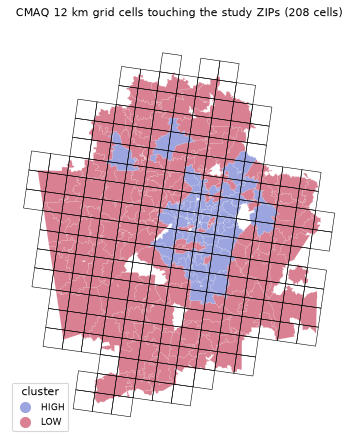

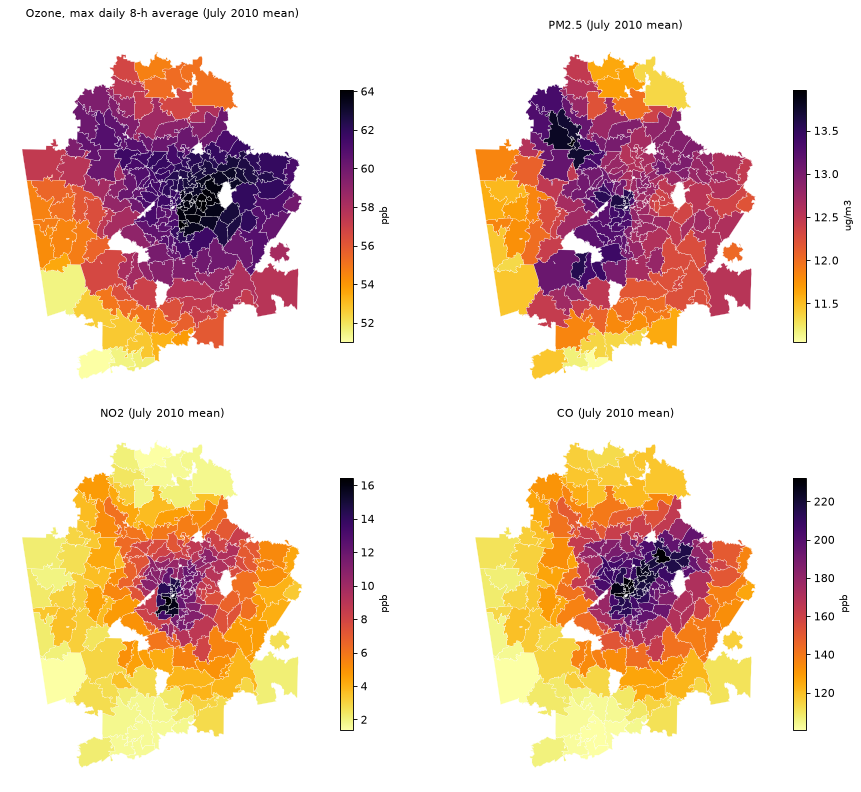

,n,n_null,pct_null,min,p25,median,p75,max,n_zero,n_negative
aq_o3_mda8_jul2010,190,0,0.0,51.007559,58.148583,60.838937,62.176070,64.089445,0,0
aq_o3_avg_jul2010,190,0,0.0,34.831456,37.570998,38.762790,40.553058,42.952426,0,0
aq_co_avg_jul2010,190,0,0.0,100.520342,126.196270,164.988146,203.242632,232.397742,0,0
aq_no_avg_jul2010,190,0,0.0,0.077752,0.304243,0.828256,1.653524,4.258216,0,0
aq_no2_avg_jul2010,190,0,0.0,1.374983,3.662395,6.620703,10.466112,16.452617,0,0
aq_so2_avg_jul2010,190,0,0.0,0.472316,0.850758,1.051605,1.339103,2.766698,0,0
aq_ch2o_avg_jul2010,190,0,0.0,3.005030,3.384976,3.460319,3.558395,3.829243,0,0
aq_pm10_avg_jul2010,190,0,0.0,16.793427,18.494237,19.002837,19.509258,20.789136,0,0
aq_pm25_avg_jul2010,190,0,0.0,11.056678,12.370961,12.737002,13.061652,13.975537,0,0
aq_pm25_so4_avg_jul2010,190,0,0.0,1.858409,2.176113,2.226825,2.288691,2.542817,0,0


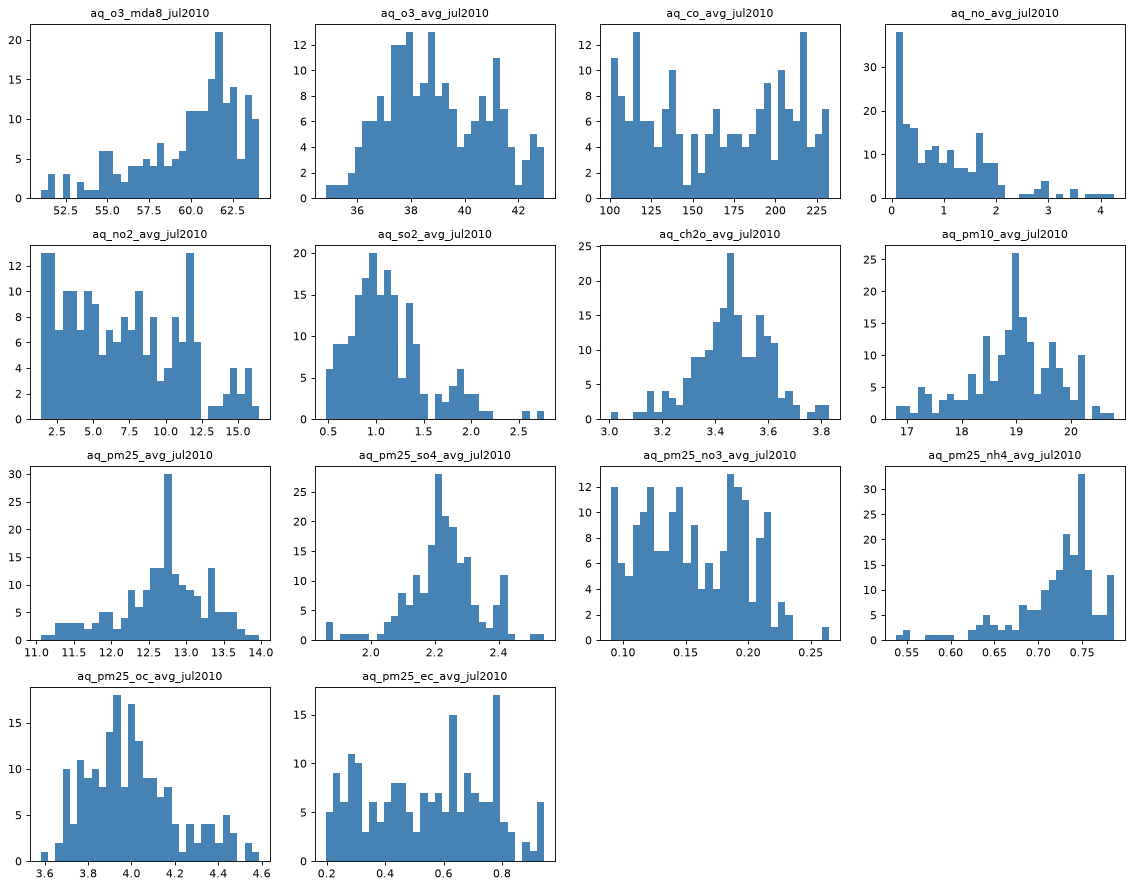

In [ ]:
pieces = gpd.overlay(zipcode_gdf[["ZIP5", "geometry"]], aq_cells_gdf[["column", "row", *AQ_FIELDS, "geometry"]], how="intersection", keep_geom_type=True)
pieces["w"] = pieces.area
sums = pieces.groupby("ZIP5")
aq_zip = pieces[list(AQ_FIELDS)].mul(pieces["w"], axis=0).groupby(pieces["ZIP5"]).sum().div(sums["w"].sum(), axis=0)
zipcode_gdf = join_zip(zipcode_gdf, aq_zip.set_axis(AQ_COLS, axis=1))

coverage = sums["w"].sum() / zipcode_gdf.set_index("ZIP5")["zip_area_sqft"]
touched = pieces[["column", "row"]].drop_duplicates()
print(f"grid-cell coverage of ZIP area: min {coverage.min():.6f}, max {coverage.max():.6f}; "
      f"distinct cells touching the study ZIPs: {len(touched)}; cells per ZIP: {sums.size().min()} to {sums.size().max()}")
assert len(coverage) == 190 and (coverage >= 0.999).all()
assert (zipcode_gdf[AQ_COLS] >= 0).all().all()

ax = zipcode_gdf.plot(column="cluster", cmap="coolwarm", alpha=0.5, edgecolor="white", linewidth=0.2, figsize=(7, 6.5), legend=True,
                      legend_kwds={"title": "cluster", "loc": "lower left", "fontsize": 8})
aq_cells_gdf.merge(touched).boundary.plot(ax=ax, color="black", linewidth=0.5)
ax.set_title(f"CMAQ 12 km grid cells touching the study ZIPs ({len(touched)} cells)")
ax.set_axis_off()
plt.show()

AQ_MAP = {"aq_o3_mda8_jul2010": ("Ozone, max daily 8-h average (July 2010 mean)", "ppb"), "aq_pm25_avg_jul2010": ("PM2.5 (July 2010 mean)", "ug/m3"),
          "aq_no2_avg_jul2010": ("NO2 (July 2010 mean)", "ppb"), "aq_co_avg_jul2010": ("CO (July 2010 mean)", "ppb")}
plot_choropleths(zipcode_gdf, list(AQ_MAP), [t for t, _ in AQ_MAP.values()], legend_labels=[u for _, u in AQ_MAP.values()], cmap="inferno_r")
sanity_report(zipcode_gdf, AQ_COLS)

## 11. Master table: overall QA

Every source is now joined onto `zipcode_gdf`, one validated one-to-one join at a time. This section
checks the assembled table:

- join coverage per source;
- a map of missing values per ZIP;
- a Spearman correlation heatmap;
- scatter plots of energy against four headline variables.

**Why Spearman.** `energy_actual_kwh` is a ZIP **total**, so it scales with population, and most
predictors are skewed. Rank correlation is robust to both. It is descriptive only: no model is fitted
here.

The land-use shares exist only for the 142 ZIPs fully covered by LandPro (Section 9), so they are
incomplete by design, and their correlations use those ZIPs only (pairwise complete).

,n_columns,n_zips_matched,n_zips_complete
CBD distance,1,190,190
MARTA rail,4,190,190
Walkability,2,190,190
Microsoft buildings,5,190,190
Socioeconomic,356,190,190
Land use (LandPro),33,190,142
Air quality (CMAQ),14,190,190


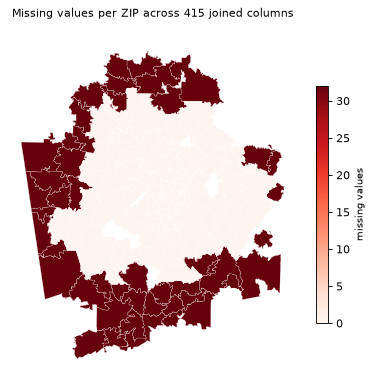

In [ ]:
JOIN_GROUPS = {
    "CBD distance": ["Dist_CBD_mi"],
    "MARTA rail": ["MARTA_stations_in_zip", "has_MARTA_station", "Dist_MARTA_Rail_mi", "Nearest_MARTA_Station"],
    "Walkability": ["NatWalkInd_zip", "D3B_zip"],
    "Microsoft buildings": MS_COLS,
    "Socioeconomic": SE_COLS,
    "Land use (LandPro)": ["landpro_coverage_frac"] + LU_COLS,
    "Air quality (CMAQ)": AQ_COLS,
}
coverage = pd.DataFrame({g: {"n_columns": len(c), "n_zips_matched": zipcode_gdf[c].notna().any(axis=1).sum(),
                             "n_zips_complete": zipcode_gdf[c].notna().all(axis=1).sum()} for g, c in JOIN_GROUPS.items()}).T
display(coverage)
assert (coverage["n_zips_matched"] == 190).all()

JOINED_COLS = sum(JOIN_GROUPS.values(), [])
plot_choropleth(zipcode_gdf.assign(n_missing=zipcode_gdf[JOINED_COLS].isna().sum(axis=1)), "n_missing",
                f"Missing values per ZIP across {len(JOINED_COLS)} joined columns", cmap="Reds", legend_label="missing values")
plt.show()

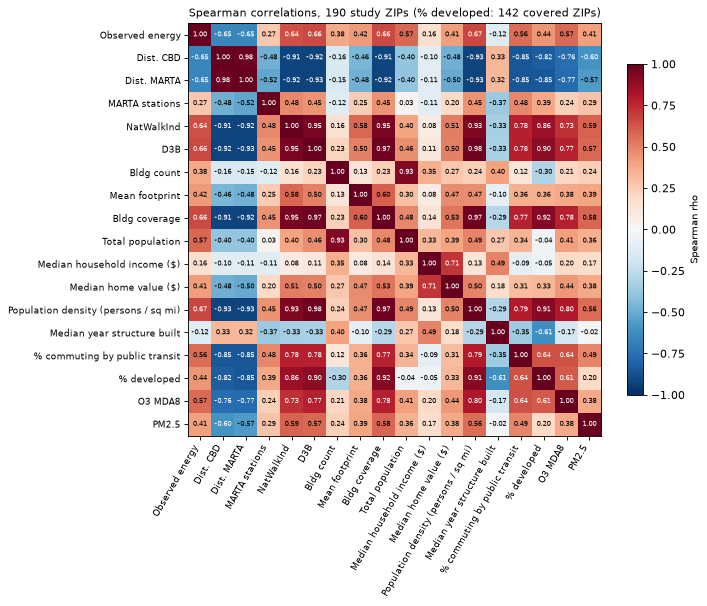

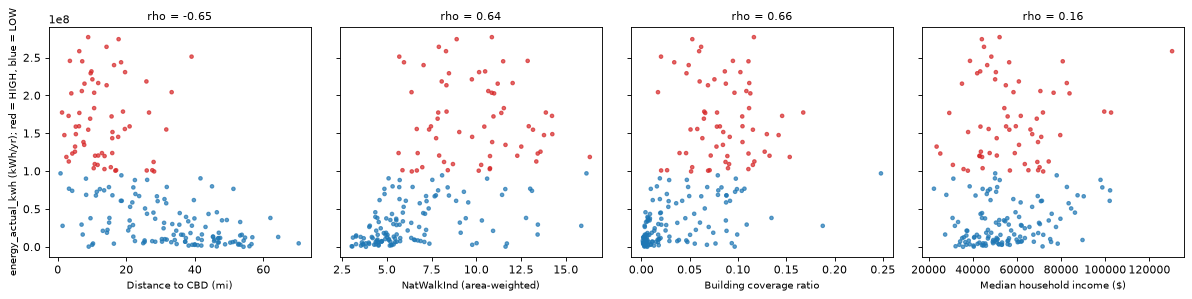

In [ ]:
CORR_VARS = {
    "energy_actual_kwh": "Observed energy", "Dist_CBD_mi": "Dist. CBD", "Dist_MARTA_Rail_mi": "Dist. MARTA",
    "MARTA_stations_in_zip": "MARTA stations", "NatWalkInd_zip": "NatWalkInd", "D3B_zip": "D3B",
    "ms_bldg_count": "Bldg count", "ms_mean_area_sqft": "Mean footprint", "ms_bldg_coverage_ratio": "Bldg coverage",
    **{c: name for name, c in KEY_SE.items()},
    "lu_pct_developed": "% developed", "aq_o3_mda8_jul2010": "O3 MDA8", "aq_pm25_avg_jul2010": "PM2.5",
}
corr = zipcode_gdf[list(CORR_VARS)].astype("float64").corr(method="spearman")
labels = list(CORR_VARS.values())
fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(labels)), labels, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(len(labels)), labels, fontsize=8)
for (i, j), v in np.ndenumerate(corr.to_numpy()):
    ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6, color="white" if abs(v) > 0.6 else "black")
fig.colorbar(im, ax=ax, shrink=0.8, label="Spearman rho")
ax.set_title("Spearman correlations, 190 study ZIPs (% developed: 142 covered ZIPs)")
fig.tight_layout()
plt.show()

SCATTER_VARS = {"Dist_CBD_mi": "Distance to CBD (mi)", "NatWalkInd_zip": "NatWalkInd (area-weighted)",
                "ms_bldg_coverage_ratio": "Building coverage ratio", KEY_SE["Median household income ($)"]: "Median household income ($)"}
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), sharey=True)
for ax, (col, lab) in zip(axes, SCATTER_VARS.items()):
    ax.scatter(zipcode_gdf[col], zipcode_gdf["energy_actual_kwh"], s=10, c=colors, alpha=0.7)
    ax.set(xlabel=lab, title=f"rho = {corr.loc[col, 'energy_actual_kwh']:.2f}")
axes[0].set_ylabel("energy_actual_kwh (kWh/yr); red = HIGH, blue = LOW")
fig.tight_layout()
plt.show()

## 12. Data dictionary and outputs

Every non-geometry column of the master table gets one dictionary row: description, unit, source and
method. The rows come from four places:
- base-layer columns from `BASE_COLUMN_DOCS` (Section 3);
- socioeconomic columns from the codebook;
- land-use and air-quality columns from their class and field lists (Sections 9 and 10);
- other derived columns from the table below.

The build fails if any column is undocumented.

**Outputs.**
- `data/processed/zipcode_data_dictionary.csv`
- `data/processed/landuse_coverage_gaps.csv`: the 48 ZIPs with LandPro coverage below 99%
  (Section 9.1).
- `data/interim/zipcode_joined.gpkg`: the 190-ZIP master table.
- `data/interim/cbd_atlanta.gpkg`, `marta_rail_stations.gpkg`, `epa_walkability.gpkg` and
  `ms_buildings.gpkg`: the inputs in EPSG:2240.
- Saved earlier: `zipcode_base.gpkg`, `socioeconomic_codebook.csv` and `socioeconomic_tract.csv`.

In [ ]:
MS_SRC = "Microsoft US Building Footprints 2018-2020"
MARTA_SRC = "MARTA rail stations 2025"
DERIVED_DOCS = pd.DataFrame(
    [
        ("pred_RF_train_kwh", "Random-forest prediction, training fit (was predictedR)", "kWh/yr", "Prior ZIP-level energy model via ArcGIS layer", "Renamed; verified 100% against RF_ZCTA_Estimates"),
        ("pred_RF_cv_kwh", "Random-forest prediction, cross-validated (was predicte_1)", "kWh/yr", "Prior ZIP-level energy model via ArcGIS layer", "Renamed; verified 100% against RF_ZCTA_Estimates"),
        ("pred_MATLAB_kwh", "MATLAB regression prediction, unreliable (was predictedm)", "kWh/yr", "Prior ZIP-level energy model via ArcGIS layer", "Renamed; verified 100% against RF_ZCTA_Estimates"),
        ("energy_actual_kwh", "Observed residential energy use (was actual)", "kWh/yr", "Energy table via ArcGIS layer", "Renamed; equals se_resid_energy_kwh of the SE source"),
        ("ZIP5", "Join key: 5-character zero-padded ZCTA code", "text", "TIGER/Line 2010 ZCTA", "ZCTA5CE10 as zero-padded string"),
        ("zip_area_sqft", "Planar ZIP polygon area (denominator of area metrics)", "sq ft", "TIGER/Line 2010 ZCTA", "geometry.area in EPSG:2240"),
        ("Dist_CBD_mi", "Euclidean distance from ZIP representative point to CBD representative point", "mi", "Atlanta CBD polygon (provided with the study data)", "Distance in EPSG:2240 ft / 5,280"),
        ("MARTA_stations_in_zip", "Number of MARTA rail stations within the ZIP", "count", MARTA_SRC, "Point-in-polygon (within); 0 where none"),
        ("has_MARTA_station", "ZIP contains at least one MARTA rail station", "boolean", MARTA_SRC, "MARTA_stations_in_zip > 0"),
        ("Dist_MARTA_Rail_mi", "Euclidean distance from ZIP representative point to nearest MARTA rail station", "mi", MARTA_SRC, "sjoin_nearest in EPSG:2240 ft / 5,280"),
        ("Nearest_MARTA_Station", "Name of the nearest MARTA rail station", "text", MARTA_SRC, "sjoin_nearest (ties: first)"),
        ("NatWalkInd_zip", "EPA National Walkability Index", "index 1-20", "EPA NWI v3.0, block groups", "Area-weighted mean over ZIP x block-group overlay"),
        ("D3B_zip", "Pedestrian-oriented street-intersection density", "intersections / sq mi", "EPA NWI v3.0, block groups", "Area-weighted mean over ZIP x block-group overlay"),
        ("ms_bldg_count", "Number of Microsoft building footprints", "count", MS_SRC, "Buildings assigned by representative point within ZIP"),
        ("ms_sum_area_sqft", "Total building footprint area", "sq ft", MS_SRC, "Sum of footprint areas (EPSG:2240)"),
        ("ms_mean_area_sqft", "Mean building footprint area", "sq ft", MS_SRC, "Mean of footprint areas (EPSG:2240)"),
        ("ms_max_area_sqft", "Largest building footprint area", "sq ft", MS_SRC, "Max of footprint areas (EPSG:2240)"),
        ("ms_bldg_coverage_ratio", "Share of ZIP area covered by building footprints", "sq ft / sq ft", MS_SRC, "ms_sum_area_sqft / zip_area_sqft"),
    ],
    columns=["column", "description", "unit", "source", "method"],
)
se_rows = codebook[codebook["se_code"].isin(SE_COLS)]
se_docs = pd.DataFrame({
    "column": se_rows["se_code"], "description": se_rows["label"],
    "unit": np.select([se_rows["label_raw"].str.startswith("Percent"), se_rows["label_raw"].str.startswith("Number")], ["%", "count"], "see label"),
    "source": "May_Zip_Tract_regular_June_2.xlsx (2011 ACS/Census)",
    "method": np.where(se_rows["in_highEE_model"] | se_rows["in_lowEE_model"], "Direct ZIP5 match; cluster-model predictor", "Direct ZIP5 match"),
})
LANDPRO_SRC = "ARC LandPro 2012 (Atlanta Regional Commission)"
LU_METHOD = "ZIP x LandPro overlay, EPSG:2240 areas; % of covered area; NaN unless landpro_coverage_frac >= 0.99"
lu_docs = pd.DataFrame(
    [("landpro_coverage_frac", "Share of ZIP area covered by LandPro polygons", "sq ft / sq ft", LANDPRO_SRC,
      "Sum of ZIP x LandPro overlay piece areas / zip_area_sqft; all ZIPs")]
    + [(c, f"Share of the LandPro-covered ZIP area in DE3 group {g}", "% of covered area", LANDPRO_SRC, LU_METHOD) for c, g in zip(LU_DE3_COLS, DE3_GROUPS)]
    + [(c, f"Share of the LandPro-covered ZIP area in land-use class {k} (LU_NAME)", "% of covered area", LANDPRO_SRC, LU_METHOD + "; 0 where absent")
       for c, k in zip(LU_CLASS_COLS, LU_CLASSES)],
    columns=["column", "description", "unit", "source", "method"],
)
aq_docs = pd.DataFrame(
    [(c, f"{desc} ({f}), July 2010 mean of daily values", unit, "EPA EQUATES CMAQ v5.3.2, 12US1 12 km grid, July 2010",
      "Mean of 31 daily values per cell; area-weighted mean over ZIP x grid-cell overlay (EPSG:2240)")
     for c, (f, (desc, unit)) in zip(AQ_COLS, AQ_FIELDS.items())],
    columns=["column", "description", "unit", "source", "method"],
)
base_docs = BASE_COLUMN_DOCS[~BASE_COLUMN_DOCS["column"].isin(PRED_RENAME)].assign(method="From the base layer, unchanged")
data_dictionary = pd.concat([base_docs, DERIVED_DOCS, se_docs, lu_docs, aq_docs]).set_index("column")
table_cols = list(zipcode_gdf.columns.drop("geometry"))
assert set(table_cols) <= set(data_dictionary.index), "undocumented columns"
data_dictionary = data_dictionary.loc[table_cols].reset_index()
data_dictionary.to_csv(PROCESSED / "zipcode_data_dictionary.csv", index=False)

zipcode_gdf.to_file(INTERIM / "zipcode_joined.gpkg", driver="GPKG")
for name, gdf in {"cbd_atlanta": cbd_gdf, "marta_rail_stations": marta_gdf, "epa_walkability": walkability_gdf,
                  "ms_buildings": ms_buildings_gdf}.items():
    gdf.to_file(INTERIM / f"{name}.gpkg", driver="GPKG")
print(f"zipcode_joined.gpkg: {zipcode_gdf.shape[0]} rows x {zipcode_gdf.shape[1]} columns; dictionary: {len(data_dictionary)} rows")
data_dictionary.head(45)

zipcode_joined.gpkg: 190 rows x 444 columns; dictionary: 443 rows


,column,description,unit,source,method
0,STATEFP10,State FIPS code (13 = Georgia),code,TIGER/Line 2010 ZCTA,"From the base layer, unchanged"
1,ZCTA5CE10,5-digit ZCTA code; source of the ZIP5 key,code,TIGER/Line 2010 ZCTA,"From the base layer, unchanged"
2,GEOID10,State FIPS + ZCTA,code,TIGER/Line 2010 ZCTA,"From the base layer, unchanged"
3,CLASSFP10,Census class code,code,TIGER/Line 2010 ZCTA,"From the base layer, unchanged"
4,MTFCC10,MAF/TIGER feature class code,code,TIGER/Line 2010 ZCTA,"From the base layer, unchanged"
5,FUNCSTAT10,Functional status,code,TIGER/Line 2010 ZCTA,"From the base layer, unchanged"
6,ALAND10,Land area (not used; see zip_area_sqft),sq m,TIGER/Line 2010 ZCTA,"From the base layer, unchanged"
7,AWATER10,Water area,sq m,TIGER/Line 2010 ZCTA,"From the base layer, unchanged"
8,INTPTLAT10,Latitude of the Census internal point,degrees,TIGER/Line 2010 ZCTA,"From the base layer, unchanged"
9,INTPTLON10,Longitude of the Census internal point,degrees,TIGER/Line 2010 ZCTA,"From the base layer, unchanged"


## 13. Pending / not yet joined

**Remote-sensing rasters (NDVI, impervious surface, LST, LAI).** These are being re-downloaded with a
larger extent. The projection and zonal-statistics method will be added once they arrive. Known issues
with the current files:
- Their extent (about −84.90 to −84.10 lon, 33.50 to 34.10 lat) covers only **112 of the 190** study
  ZIPs.
- The LAI maximum of **25.5** looks like a fill value (physical LAI tops out around 10). To be
  confirmed.

**Not yet in this pipeline:**
- MARTA bus stops and routes
- TIGER 2012 primary/secondary roads (arterial density). The 2012 TIGER `prisecroads` file is
  identified but not yet added.
- NLCD tree canopy

**Tract-level thread.** The socioeconomic tract rows are cleaned, keyed by `TractGeoID` and saved in
`data/interim/socioeconomic_tract.csv`.